# 🧬 MoleGuLAR: Molecule Generation using Reinforcement Learning and Alternating Rewards

This notebook implements the **full MoleGuLAR pipeline** for *de novo* drug-like molecule generation using:- A **Stack-Augmented RNN** generative model- **Reinforcement Learning** (REINFORCE / policy gradient) for property optimization- **Alternating reward** strategy for multi-objective optimization**Target proteins**: SARS-CoV-2 Mᵖʳᵒ (6LU7) and TTBK1 (4BTK)

**Reference**: [MoleGuLAR Paper](https://github.com/devalab/MoleGuLAR)

Furthermore, it tries to implement interpretability through an SSINet, ispired by the paper
> Self-Supervised Discovering of Interpretable
Features for Reinforcement Learning from Shi et al




## 📥 Setup & Installation
Install all required dependencies and clone the MoleGuLAR repo for data files.

In [1]:
!pip uninstall -y torch torchvision torchaudio dgl dgllife torchdata -q
!pip cache purge -q

### 🟢 Cuda

In [2]:
# Detect CUDA version from the system
import subprocess
cuda_raw = subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout
print(cuda_raw[:300])  # confirm GPU is visible

# Install torch FIRST, pinned to a real stable release
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
    --index-url https://download.pytorch.org/whl/cu121 -q

# Install DGL matched to torch 2.3 + cu121
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html -q

# Rest of the stack, numpy unpinned
!pip install dgllife rdkit -q
!pip install scikit-learn pandas matplotlib seaborn tqdm joblib wandb -q

print("✓ All packages installed")

Wed Jun  3 08:07:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 96.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 101.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6

## ⚙️ Session Setup
Platform detection, secrets, Drive mount, MoleGuLAR repo clone, and GitHub helpers. **Always run this cell first.**


In [3]:
import os, sys, subprocess, shutil
from datetime import datetime

# ── Platform detection ────────────────────────────────────────────────────────
is_kaggle        = os.path.exists('/kaggle/working') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
PLATFORM         = 'KAGGLE' if is_kaggle else ('COLAB' if os.path.exists('/var/colab/hostname') else 'OTHER')
BASE_WORKING_DIR = '/kaggle/working' if is_kaggle else ('/content' if PLATFORM == 'COLAB' else os.getcwd())
print(f'Platform: {PLATFORM}  |  Base: {BASE_WORKING_DIR}')

# ── Secret retrieval (Kaggle → Colab → env) ───────────────────────────────────
def _get_secret(name: str) -> str:
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name) or ''
        if v: return v
    except Exception: pass
    try:
        from google.colab import userdata
        v = userdata.get(name) or ''
        if v: return v
    except Exception: pass
    return os.getenv(name, '').strip()

def _get_github_token() -> str: return _get_secret('GITHUB_TOKEN')

WANDB_API_KEY = _get_secret('WANDB_API_KEY')
if WANDB_API_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY
    print('✅ W&B API key loaded')
else:
    print('⚠️  W&B API key not found — set WANDB_API_KEY in secrets')

# ── Google Drive (Colab only) ─────────────────────────────────────────────────
if PLATFORM == 'COLAB':
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        print('✅ Google Drive mounted')
    except Exception as e:
        print(f'⚠️  Drive mount skipped: {e}')

# ── Clone MoleGuLAR repo ──────────────────────────────────────────────────────
REPO_URL      = 'https://github.com/devalab/MoleGuLAR.git'
REPO_DIR      = os.path.join(BASE_WORKING_DIR, 'MoleGuLAR')
OPTIMIZER_DIR = os.path.join(REPO_DIR, 'Optimizer')

try:
    subprocess.run(['git', 'lfs', 'version'], check=True, capture_output=True)
except (subprocess.CalledProcessError, FileNotFoundError):
    subprocess.run(['apt-get', 'install', '-y', '-q', 'git-lfs'], check=True)
    subprocess.run(['git', 'lfs', 'install'], check=True)
    print('git-lfs installed')

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, REPO_DIR], check=True)
    subprocess.run(['git', 'lfs', 'pull'], cwd=REPO_DIR, check=True)
else:
    subprocess.run(['git', 'lfs', 'pull'], cwd=REPO_DIR, capture_output=True)

os.chdir(OPTIMIZER_DIR)
sys.path.insert(0, os.path.join(OPTIMIZER_DIR, 'release'))

for _f in ['random.smi', 'checkpoints/generator/checkpoint_biggest_rnn',
           'Predictors/GINPredictor.tar', 'Predictors/SolvationPredictor.tar']:
    _p    = os.path.join(OPTIMIZER_DIR, _f)
    _ok   = os.path.exists(_p)
    _stub = _ok and os.path.getsize(_p) < 512
    print(f"  {'⚠️ LFS stub' if _stub else '✅' if _ok else '❌ missing':13s} {_f}")

# ── GitHub helpers ────────────────────────────────────────────────────────────
def save_snapshot():
    """Copy model weights + metrics into CKPT_DIR. Images/plots written
    directly by their cells. Generated molecules CSV written to NEW_MOLECULES_DIR."""
    for _d in [CKPT_DIR, IMAGES_DIR, PLOTS_DIR, NEW_MOLECULES_DIR]:
        os.makedirs(_d, exist_ok=True)
    if os.path.exists(MODEL_NAME):
        shutil.copy2(MODEL_NAME, os.path.join(CKPT_DIR, os.path.basename(MODEL_NAME)))
    for _src in [LOSS_FILE, REWARD_FILE, PRED_FILE]:
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(CKPT_DIR, os.path.basename(_src)))
    if os.path.exists(MOL_DIR):
        for _f in os.listdir(MOL_DIR):
            if _f.endswith(('.smi', '.txt', '.csv', '.json')):
                shutil.copy2(os.path.join(MOL_DIR, _f), os.path.join(CKPT_DIR, _f))
    print(f'[Snapshot] → {CKPT_DIR}')


def push_to_github(label: str = 'checkpoint'):
    """Mirror outputs/<run_type>/ to GitHub. Token injected at push time."""
    if not PUSH_TO_GITHUB:
        return
    token = _get_github_token()
    if not token:
        print('[GitHub] ⚠️  GITHUB_TOKEN not found — skipping.'); return
    if '://' not in GITHUB_REPO_URL:
        print('[GitHub] ❌  Malformed GITHUB_REPO_URL.'); return
    proto, rest = GITHUB_REPO_URL.split('://', 1)
    auth_url    = f'{proto}://{token}@{rest}'
    tmp = os.path.join(os.path.dirname(KAGGLE_OUTPUT_DIR), '.gh_tmp')
    try:
        if os.path.exists(tmp): shutil.rmtree(tmp)
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', GITHUB_BRANCH,
                        auth_url, tmp], check=True, capture_output=True, timeout=120)
        for cmd in [['git', 'config', 'user.name',  'MoleGuLAR-Bot'],
                    ['git', 'config', 'user.email', 'bot@mole.local']]:
            subprocess.run(cmd, cwd=tmp, check=True, capture_output=True)
        ts      = datetime.now().strftime('%Y%m%d_%H%M%S')
        out_dir = os.path.join(tmp, 'outputs',
                               'alternate_rewards' if SWITCH_MODE else 'weighted_sum')
        if os.path.exists(out_dir): shutil.rmtree(out_dir)
        shutil.copytree(KAGGLE_OUTPUT_DIR, out_dir)
        with open(os.path.join(out_dir, 'metadata.txt'), 'w') as mf:
            for k, v in [('Timestamp', ts), ('Run name', REMARKS), ('Label', label),
                         ('Platform', PLATFORM), ('PREDICTOR', PREDICTOR),
                         ('PROTEIN', PROTEIN), ('REWARD_FUNCTION', REWARD_FUNCTION),
                         ('NUM_ITERATIONS', NUM_ITERATIONS), ('N_POLICY', N_POLICY),
                         ('SWITCH_MODE', SWITCH_MODE), ('SWITCH_FREQUENCY', SWITCH_FREQUENCY),
                         ('USE_LOGP', USE_LOGP), ('USE_QED', USE_QED), ('USE_TPSA', USE_TPSA)]:
                mf.write(f'{k:<16}: {v}\n')
        subprocess.run(['git', 'add', '-A'], cwd=tmp, check=True, capture_output=True)
        msg = f'[AUTO] {REMARKS} | {label} @ {ts}'
        res = subprocess.run(['git', 'commit', '-m', msg],
                             cwd=tmp, capture_output=True, text=True)
        if 'nothing to commit' in res.stdout:
            print('[GitHub] Nothing new to commit.'); return
        subprocess.run(['git', 'push', 'origin', GITHUB_BRANCH],
                       cwd=tmp, check=True, capture_output=True, timeout=180)
        print(f'[GitHub] ✅ Pushed: {msg}')
    except subprocess.TimeoutExpired:
        print('[GitHub] ⚠️  Timed out.')
    except subprocess.CalledProcessError as e:
        print(f'[GitHub] ⚠️  Failed: {(e.stderr or b"").decode()[:200]}')
    except Exception as e:
        print(f'[GitHub] ⚠️  {e}')
    finally:
        if os.path.exists(tmp): shutil.rmtree(tmp, ignore_errors=True)


print('✅ Session setup complete')


Platform: KAGGLE  |  Base: /kaggle/working
✅ W&B API key loaded


Cloning into '/kaggle/working/MoleGuLAR'...


  ✅             random.smi
  ✅             checkpoints/generator/checkpoint_biggest_rnn
  ✅             Predictors/GINPredictor.tar
  ✅             Predictors/SolvationPredictor.tar
✅ Session setup complete


Updating files: 100% (49/49), done.


###  📥Imports

In [4]:
import torch, dgl, rdkit, sklearn, pandas, csv, time, warnings, os, sys, threading, random, shutil, joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import SVG, display
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit import DataStructs
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.QED import qed
from rdkit.Chem.rdMolDescriptors import CalcTPSA

from sklearn.model_selection import KFold

import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

from dgl.nn.pytorch.glob import AvgPooling
from dgllife.utils import (
    mol_to_bigraph,
    PretrainAtomFeaturizer,
    PretrainBondFeaturizer,
    smiles_to_bigraph,
    CanonicalAtomFeaturizer,
    CanonicalBondFeaturizer
)
from dgllife.model import load_pretrained
from dgllife.model import MPNNPredictor

from tqdm import tqdm, trange


print(f"PyTorch  : {torch.__version__}")
print(f"CUDA ok  : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"DGL      : {dgl.__version__}")
print(f"RDKit    : {rdkit.__version__}")
print(f"sklearn  : {sklearn.__version__}")
print(f"pandas   : {pandas.__version__}")
print(f"numpy    : {np.__version__}")

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
PyTorch  : 2.3.1+cu121
CUDA ok  : True — Tesla T4
DGL      : 2.5.0+cu121
RDKit    : 2026.03.2
sklearn  : 1.6.1
pandas   : 2.3.3
numpy    : 2.0.2


## 🎛️ Configuration

Adjust experiment parameters below. This replaces the command-line `argparse` used in the original scripts.
| Parameter | Description |
|---|---|
| `PREDICTOR` | `"gin"` (recommended, no AutoDock needed) or `"dock"` (requires AutoDock-GPU) |
| `PROTEIN` | `"4BTK"` (TTBK1) or `"6LU7"` (SARS-CoV-2 Mᵖʳᵒ) — note: GIN only supports 4BTK |
| `REWARD_FUNCTION` | `"exponential"`, `"linear"`, `"logarithmic"`, or `"squared"` |
| `NUM_ITERATIONS` | Number of RL training iterations (default 175, use fewer for quick tests) |
| `USE_LOGP / USE_QED / ...` | Enable multi-objective optimization targets |
| `SWITCH_MODE` | `True` = alternating rewards, `False` = weighted sum |

In [5]:
# ── Predictor & Target ──
PREDICTOR = "gin"        # "gin" | "rfr" | "dock"
PROTEIN   = "4BTK"       # "4BTK" | "6LU7"

# ── Reward Function ──
REWARD_FUNCTION = "exponential"   # "exponential" | "linear" | "logarithmic" | "squared"

# ── Model selection ──
# "original"         → MoleGuLAR base pretrained RNN (no fine-tuning)
# "alternate-rewards" → your trained checkpoint in outputs/alternate_rewards/
# "weighted-sum"      → your trained checkpoint in outputs/weighted_sum/
MODEL = "original"

# ── Training ──
NUM_ITERATIONS = 175      # Paper value (Goel et al.)
N_POLICY       = 15       # Paper value
N_TO_GENERATE  = 100      # Paper value
SEED           = 42

# ── Multi-Objective Targets ──
USE_LOGP      = True
USE_QED       = True
USE_TPSA      = True
USE_SOLVATION = False

# ── Thresholds ──
LOGP_THRESHOLD      = 2.5
QED_THRESHOLD       = 0.8
TPSA_THRESHOLD      = 100.0
SOLVATION_THRESHOLD = -10.0

# ── Alternating Rewards ──
SWITCH_MODE      = True
SWITCH_FREQUENCY = 15     # Paper value — cycles (docking / LogP / QED) every 35 iters

# ── Logging ──
USE_WANDB       = True
REMARKS         = "alternate-rewards-SSINet"
USE_CHECKPOINT  = False
ADAPTIVE_REWARD = True

# ── GitHub Integration ──
# Set PUSH_TO_GITHUB = True and store your PAT in Kaggle Secrets as "GITHUB_TOKEN".
# The URL should NOT contain the token — it is injected at push time.
PUSH_TO_GITHUB  = True
GITHUB_REPO_URL = "https://github.com/Pimpi7/RL-Project.git"   # no token here
GITHUB_BRANCH   = "master"

# How often (every N iterations) to checkpoint the model AND push to GitHub.
# Set to 0 to push only at the end.
CHECKPOINT_EVERY = 25     # Save + push every 25 iterations

# ── Output folder structure ──────────────────────────────────────────────
# outputs/
#   alternate_rewards/   (MODEL='alternate-rewards'  or  MODEL='original' + SWITCH_MODE=True)
#   weighted_sum/        (MODEL='weighted-sum'       or  MODEL='original' + SWITCH_MODE=False)
#     checkpoints/       model weights, training metrics
#     images/            molecular heatmaps (SSINet + batch top-5)
#     plots/             training curves, histograms, violin plots
#     new_molecules/     generated molecules CSV (post-training analysis)
import os
_base = "/kaggle/working" if os.path.exists("/kaggle/working") else os.getcwd()
# MODEL drives folder selection; SWITCH_MODE only used for fresh training runs
if MODEL == "original":
    _run_type = "alternate_rewards" if SWITCH_MODE else "weighted_sum"
elif MODEL == "alternate-rewards":
    _run_type = "alternate_rewards"
else:
    _run_type = "weighted_sum"
KAGGLE_OUTPUT_DIR  = os.path.join(_base, "outputs", _run_type)
CKPT_DIR           = os.path.join(KAGGLE_OUTPUT_DIR, "checkpoints")
IMAGES_DIR         = os.path.join(KAGGLE_OUTPUT_DIR, "images")
PLOTS_DIR          = os.path.join(KAGGLE_OUTPUT_DIR, "plots")
NEW_MOLECULES_DIR  = os.path.join(KAGGLE_OUTPUT_DIR, "new_molecules")
for _d in [CKPT_DIR, IMAGES_DIR, PLOTS_DIR, NEW_MOLECULES_DIR]:
    os.makedirs(_d, exist_ok=True)
print(f"Output root : {KAGGLE_OUTPUT_DIR}")
print(f"  → checkpoints/  images/  plots/  new_molecules/  created")


Output root : /kaggle/working/outputs/alternate_rewards
  → checkpoints/  images/  plots/  new_molecules/  created


### 🔎 Interpretability Parameters

In [6]:
USE_INTERPRET      = True     # TEST (keep True to verify SSINet pipeline)

# Core training hyperparameters
INTERPRET_ALPHA    = 0.01   # L0 sparsity weight (Hard-Concrete gates):
                             #   scales the expected number of OPEN gates
                             #   higher → fewer selected atoms (sharper mask)
                             #   lower  → more atoms retained
INTERPRET_EPOCHS   = 80     # Paper / full-run value
INTERPRET_LR       = 5e-4   # Adam learning rate for the mask MLP
INTERPRET_BATCH    = 32     # Paper / full-run value — InfoNCE batch size
INTERPRET_HIDDEN   = 64     # Hidden dim of the mask MLP (light — only 2 linear layers)

# Visualization
INTERPRET_SMILES   = None   # A specific SMILES string to explain.
                             # None → automatically pick the best molecule
                             # from the RL run (lowest predicted binding affinity).

## 🔧 Utility Modules

In [7]:
def get_fp(smiles):
    # Build fingerprint vectors and keep index maps for valid/invalid SMILES.
    fp = []
    processed_indices = []
    invalid_indices = []
    for i in range(len(smiles)):
        mol = smiles[i]
        tmp = np.array(mol2image(mol, n=2048))
        if np.isnan(tmp[0]):
            # Keep track of molecules that failed fingerprint generation.
            invalid_indices.append(i)
        else:
            fp.append(tmp)
            processed_indices.append(i)
    return np.array(fp), processed_indices, invalid_indices


def get_desc(smiles, calc):
    # Compute descriptor arrays using a descriptor calculator callable.
    desc = []
    processed_indices = []
    invalid_indices = []
    for i in range(len(smiles)):
        sm = smiles[i]
        try:
            mol = Chem.MolFromSmiles(sm)
            tmp = np.array(calc(mol))
            desc.append(tmp)
            processed_indices.append(i)
        except:
            # Keep row alignment information for downstream filtering.
            invalid_indices.append(i)

    desc_array = np.array(desc)
    return desc_array, processed_indices, invalid_indices


def normalize_desc(desc_array, desc_mean=None):
    # Replace non-finite descriptor values with column means.
    desc_array = np.array(desc_array).reshape(len(desc_array), -1)
    ind = np.zeros(desc_array.shape)
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            try:
                if np.isfinite(desc_array[i, j]):
                    ind[i, j] = 1
            except:
                pass
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            if ind[i, j] == 0:
                desc_array[i, j] = 0
    if desc_mean is None:
        # Fit normalization statistics if not provided.
        desc_mean = np.mean(desc_array, axis=0)
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            if ind[i, j] == 0:
                desc_array[i, j] = desc_mean[j]
    return desc_array, desc_mean


def mol2image(x, n=2048):
    # Convert a SMILES string into an RDKit path fingerprint vector.
    try:
        m = Chem.MolFromSmiles(x)
        fp = Chem.RDKFingerprint(m, maxPath=4, fpSize=n)
        res = np.zeros(len(fp))
        DataStructs.ConvertToNumpyArray(fp, res)
        return res
    except:
        # Return a NaN sentinel so caller can mark this SMILES as invalid.
        return [np.nan]


def sanitize_smiles(smiles, canonical=True, throw_warning=False):
    """
    Takes list of SMILES strings and returns list of their sanitized versions.

    Parameters
    ----------
    smiles: list
        list of SMILES strings

    canonical: bool (default True)
        parameter specifying whether SMILES will be converted to canonical
        format

    throw_warning: bool (default False)
        parameter specifying whether warnings will be thrown if a SMILES is
        invalid

    Returns
    -------
    new_smiles: list
        list of SMILES and NaNs if SMILES string is invalid or unsanitized.
        If canonical is True, returns list of canonical SMILES.

    When canonical is True this function is analogous to:
        canonical_smiles(smiles, sanitize=True).
    """
    new_smiles = []
    for sm in smiles:
        try:
            if canonical:
                new_smiles.append(Chem.MolToSmiles(Chem.MolFromSmiles(sm, sanitize=True)))
            else:
                new_smiles.append(sm)
        except:
            if throw_warning:
                warnings.warn('Unsanitized SMILES string: ' + sm, UserWarning)
            new_smiles.append('')
    return new_smiles


def canonical_smiles(smiles, sanitize=True, throw_warning=False):
    """
    Takes list of SMILES strings and returns list of their canonical SMILES.

    Parameters
    ----------
    smiles: list
        list of SMILES strings to convert into canonical format

    sanitize: bool (default True)
        parameter specifying whether to sanitize SMILES or not.
            For definition of sanitized SMILES check
            http://www.rdkit.org/docs/api/rdkit.Chem.rdmolops-module.html#SanitizeMol

    throw_warning: bool (default False)
        parameter specifying whether warnings will be thrown if a SMILES is
        invalid

    Returns
    -------
    new_smiles: list
        list of canonical SMILES and NaNs if SMILES string is invalid or
        unsanitized (when sanitize is True)

    When sanitize is True the function is analogous to:
        sanitize_smiles(smiles, canonical=True).
    """
    new_smiles = []
    for sm in smiles:
        try:
            mol = Chem.MolFromSmiles(sm, sanitize=sanitize)
            new_smiles.append(Chem.MolToSmiles(mol))
        except:
            if throw_warning:
                warnings.warn(sm + ' can not be canonized: invalid '
                                   'SMILES string!', UserWarning)
            new_smiles.append('')
    return new_smiles


def save_smi_to_file(filename, smiles, unique=True):
    """
    Takes path to file and list of SMILES strings and writes SMILES to the specified file.

        Args:
            filename (str): path to the file
            smiles (list): list of SMILES strings
            unique (bool): parameter specifying whether to write only unique copies or not.

        Output:
            success (bool): defines whether operation was successfully completed or not.
       """
    if unique:
        smiles = list(set(smiles))
    else:
        smiles = list(smiles)
    f = open(filename, 'w')
    for mol in smiles:
        f.writelines([mol, '\n'])
    f.close()
    return f.closed


def read_smi_file(filename, unique=True, add_start_end_tokens=False):
    """
    Reads SMILES from file. File must contain one SMILES string per line
    with \n token in the end of the line.

    Args:
        filename (str): path to the file
        unique (bool): return only unique SMILES

    Returns:
        smiles (list): list of SMILES strings from specified file.
        success (bool): defines whether operation was successfully completed or not.

    If 'unique=True' this list contains only unique copies.
    """
    f = open(filename, 'r')
    molecules = []
    for line in f:
        if add_start_end_tokens:
            molecules.append('<' + line[:-1] + '>')
        else:
            molecules.append(line[:-1])
    if unique:
        molecules = list(set(molecules))
    else:
        molecules = list(molecules)
    f.close()
    return molecules, f.closed


def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def cross_validation_split(x, y, n_folds=5, split='random', folds=None):
    assert(len(x) == len(y))
    x = np.array(x)
    y = np.array(y)
    if split not in ['random', 'stratified', 'fixed']:
        raise ValueError('Invalid value for argument \'split\': '
                         'must be either \'random\', \'stratified\' '
                         'or \'fixed\'')
    if split == 'random':
        cv_split = KFold(n_splits=n_folds, shuffle=True)
        folds = list(cv_split.split(x, y))
    elif split == 'stratified':
        cv_split = StratifiedKFold(n_splits=n_folds, shuffle=True)
        folds = list(cv_split.split(x, y))
    elif split == 'fixed' and folds is None:
        raise TypeError(
            'Invalid type for argument \'folds\': found None, but must be list')
    cross_val_data = []
    cross_val_labels = []
    if len(folds) == n_folds:
        for fold in folds:
            cross_val_data.append(x[fold[1]])
            cross_val_labels.append(y[fold[1]])
    elif len(folds) == len(x) and np.max(folds) == n_folds:
        for f in range(n_folds):
            left = np.where(folds == f)[0].min()
            right = np.where(folds == f)[0].max()
            cross_val_data.append(x[left:right + 1])
            cross_val_labels.append(y[left:right + 1])

    return cross_val_data, cross_val_labels


def read_object_property_file(path, delimiter=',', cols_to_read=[0, 1],
                              keep_header=False):
    f = open(path, 'r')
    reader = csv.reader(f, delimiter=delimiter)
    data_full = np.array(list(reader))
    if keep_header:
        start_position = 0
    else:
        start_position = 1
    assert len(data_full) > start_position
    data = [[] for _ in range(len(cols_to_read))]
    for i in range(len(cols_to_read)):
        col = cols_to_read[i]
        data[i] = data_full[start_position:, col]
    f.close()
    if len(cols_to_read) == 1:
        data = data[0]
    return data

### 🧩 Tokenizer

In [8]:

def tokenize(smiles, tokens=None):
    """
    Returns list of unique tokens, token-2-index dictionary and number of
    unique tokens from the list of SMILES

    Parameters
    ----------
        smiles: list
            list of SMILES strings to tokenize.

        tokens: list, str (default None)
            list of unique tokens

    Returns
    -------
        tokens: list
            list of unique tokens/SMILES alphabet.

        token2idx: dict
            dictionary mapping token to its index.

        num_tokens: int
            number of unique tokens.
    """
    if tokens is None:
        tokens = list(set(''.join(smiles)))
        tokens = list(np.sort(tokens))
        tokens = ''.join(tokens)
    token2idx = dict((token, i) for i, token in enumerate(tokens))
    num_tokens = len(tokens)
    return tokens, token2idx, num_tokens

###  🔁 Iterators

In [9]:
class Iterator(object):
    """Abstract base class for data iterators.
    # Arguments
        n: Integer, total number of samples in the dataset to loop over.
        batch_size: Integer, size of a batch.
        shuffle: Boolean, whether to shuffle the data between epochs.
        seed: Random seeding for data shuffling.
    """

    def __init__(self, n, batch_size, shuffle, seed):
        self.n = n
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.batch_index = 0
        self.total_batches_seen = 0
        self.lock = threading.Lock()
        self.index_generator = self._flow_index(n, batch_size, shuffle, seed)
        if n < batch_size:
            raise ValueError('Input data length is shorter than batch_size\nAdjust batch_size')

    def reset(self):
        self.batch_index = 0

    def _flow_index(self, n, batch_size=32, shuffle=False, seed=None):
        # Ensure self.batch_index is 0.
        self.reset()
        while 1:
            if seed is not None:
                np.random.seed(seed + self.total_batches_seen)
            if self.batch_index == 0:
                index_array = np.arange(n)
                if shuffle:
                    index_array = np.random.permutation(n)

            current_index = (self.batch_index * batch_size) % n
            if n > current_index + batch_size:
                current_batch_size = batch_size
                self.batch_index += 1
            else:
                current_batch_size = n - current_index
                self.batch_index = 0
            self.total_batches_seen += 1
            yield (index_array[current_index: current_index + current_batch_size],
                   current_index, current_batch_size)

    def __iter__(self):
        # Needed if we want to do something like:
        # for x, y in data_gen.flow(...):
        return self

    def __next__(self, *args, **kwargs):
        return self.next(*args, **kwargs)


class SmilesIterator(Iterator):
    """Iterator yielding data from a SMILES array.
    # Arguments
        x: Numpy array of SMILES input data.
        y: Numpy array of targets data.
        smiles_data_generator: Instance of `SmilesEnumerator`
            to use for random SMILES generation.
        batch_size: Integer, size of a batch.
        shuffle: Boolean, whether to shuffle the data between epochs.
        seed: Random seed for data shuffling.
        dtype: dtype to use for returned batch. Set to keras.backend.floatx if using Keras
    """

    def __init__(self, x, y, smiles_data_generator,
                 batch_size=32, shuffle=False, seed=None,
                 dtype=np.float32
                 ):
        if y is not None and len(x) != len(y):
            raise ValueError('X (images tensor) and y (labels) '
                             'should have the same length. '
                             'Found: X.shape = %s, y.shape = %s' %
                             (np.asarray(x).shape, np.asarray(y).shape))

        self.x = np.asarray(x)

        if y is not None:
            self.y = np.asarray(y)
        else:
            self.y = None
        self.smiles_data_generator = smiles_data_generator
        self.dtype = dtype
        super(SmilesIterator, self).__init__(x.shape[0], batch_size, shuffle, seed)

    def next(self):
        """For python 2.x.
        # Returns
            The next batch.
        """
        # Keeps under lock only the mechanism which advances
        # the indexing of each batch.
        with self.lock:
            index_array, current_index, current_batch_size = next(self.index_generator)
        # The transformation of images is not under thread lock
        # so it can be done in parallel
        batch_x = np.zeros(
            tuple([current_batch_size] + [self.smiles_data_generator.pad, self.smiles_data_generator._charlen]),
            dtype=self.dtype)
        for i, j in enumerate(index_array):
            smiles = self.x[j:j + 1]
            x = self.smiles_data_generator.transform(smiles)
            batch_x[i] = x

        if self.y is None:
            return batch_x
        batch_y = self.y[index_array]
        return batch_x, batch_y

### 🔢 Enumerator

In [10]:
class SmilesEnumerator(object):
    """SMILES Enumerator, vectorizer and devectorizer

    #Arguments
        charset: string containing the characters for the vectorization
          can also be generated via the .fit() method
        pad: Length of the vectorization
        leftpad: Add spaces to the left of the SMILES
        isomericSmiles: Generate SMILES containing information about stereogenic centers
        enum: Enumerate the SMILES during transform
        canonical: use canonical SMILES during transform (overrides enum)
    """

    def __init__(self, charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True,
                 canonical=False):
        self._charset = None
        self.charset = charset
        self.pad = pad
        self.leftpad = leftpad
        self.isomericSmiles = isomericSmiles
        self.enumerate = enum
        self.canonical = canonical

    @property
    def charset(self):
        return self._charset

    @charset.setter
    def charset(self, charset):
        self._charset = charset
        self._charlen = len(charset)
        self._char_to_int = dict((c, i) for i, c in enumerate(charset))
        self._int_to_char = dict((i, c) for i, c in enumerate(charset))

    def fit(self, smiles, extra_chars=[], extra_pad=5):
        """Performs extraction of the charset and length of a SMILES datasets and sets self.pad and self.charset

        #Arguments
            smiles: Numpy array or Pandas series containing smiles as strings
            extra_chars: List of extra chars to add to the charset (e.g. "\\\\" when "/" is present)
            extra_pad: Extra padding to add before or after the SMILES vectorization
        """
        charset = set("".join(list(smiles)))
        self.charset = "".join(charset.union(set(extra_chars)))
        self.pad = max([len(smile) for smile in smiles]) + extra_pad

    def randomize_smiles(self, smiles):
        """Perform a randomization of a SMILES string
        must be RDKit sanitizable"""
        m = Chem.MolFromSmiles(smiles)
        ans = list(range(m.GetNumAtoms()))
        np.random.shuffle(ans)
        nm = Chem.RenumberAtoms(m, ans)
        return Chem.MolToSmiles(nm, canonical=self.canonical, isomericSmiles=self.isomericSmiles)

    def transform(self, smiles):
        """Perform an enumeration (randomization) and vectorization of a Numpy array of smiles strings
        #Arguments
            smiles: Numpy array or Pandas series containing smiles as strings
        """
        one_hot = np.zeros((smiles.shape[0], self.pad, self._charlen), dtype=np.int8)

        for i, ss in enumerate(smiles):
            if self.enumerate: ss = self.randomize_smiles(ss)
            for j, c in enumerate(ss):
                one_hot[i, j, self._char_to_int[c]] = 1
        return one_hot

    def reverse_transform(self, vect):
        """ Performs a conversion of a vectorized SMILES to a smiles strings
        charset must be the same as used for vectorization.
        #Arguments
            vect: Numpy array of vectorized SMILES.
        """
        smiles = []
        for v in vect:
            # mask v
            v = v[v.sum(axis=1) == 1]
            # Find one hot encoded index with argmax, translate to char and join to string
            smile = "".join(self._int_to_char[i] for i in v.argmax(axis=1))
            smiles.append(smile)
        return np.array(smiles)

### 📤 Data Loading & Processing

In [11]:
class GeneratorData(object):
    """
    Docstring coming soon...
    """
    def __init__(self, training_data_path, tokens=None, start_token='<',
                 end_token='>', max_len=120, use_cuda=None, **kwargs):
        """
        Constructor for the GeneratorData object.

        Parameters
        ----------
        training_data_path: str
            path to file with training dataset. Training dataset must contain
            a column with training strings. The file also may contain other
            columns.

        tokens: list (default None)
            list of characters specifying the language alphabet. Of left
            unspecified, tokens will be extracted from data automatically.

        start_token: str (default '<')
            special character that will be added to the beginning of every
            sequence and encode the sequence start.

        end_token: str (default '>')
            special character that will be added to the end of every
            sequence and encode the sequence end.

        max_len: int (default 120)
            maximum allowed length of the sequences. All sequences longer than
            max_len will be excluded from the training data.

        use_cuda: bool (default None)
            parameter specifying if GPU is used for computations. If left
            unspecified, GPU will be used if available

        kwargs: additional positional arguments
            These include cols_to_read (list, default [0]) specifying which
            column in the file with training data contains training sequences
            and delimiter (str, default ',') that will be used to separate
            columns if there are multiple of them in the file.

        """
        super(GeneratorData, self).__init__()

        if 'cols_to_read' not in kwargs:
            kwargs['cols_to_read'] = []

        data = read_object_property_file(training_data_path,
                                                       **kwargs)
        self.start_token = start_token
        self.end_token = end_token
        self.file = []
        for i in range(len(data)):
            if len(data[i]) <= max_len:
                self.file.append(self.start_token + data[i] + self.end_token)
        self.file_len = len(self.file)
        self.all_characters, self.char2idx, \
        self.n_characters = tokenize(self.file, tokens)
        self.use_cuda = use_cuda
        if self.use_cuda is None:
            self.use_cuda = torch.cuda.is_available()

    def load_dictionary(self, tokens, char2idx):
        self.all_characters = tokens
        self.char2idx = char2idx
        self.n_characters = len(tokens)

    def random_chunk(self):
        """
        Samples random SMILES string from generator training data set.
        Returns:
            random_smiles (str).
        """
        index = random.randint(0, self.file_len-1)
        return self.file[index]

    def char_tensor(self, string):
        """
        Converts SMILES into tensor of indices wrapped into torch.autograd.Variable.
        Args:
            string (str): input SMILES string
        Returns:
            tokenized_string (torch.autograd.Variable(torch.tensor))
        """
        tensor = torch.zeros(len(string)).long()
        for c in range(len(string)):
            tensor[c] = self.all_characters.index(string[c])
        if self.use_cuda:
            return tensor.cuda()
        else:
            return tensor

    def random_training_set(self, smiles_augmentation):
        chunk = self.random_chunk()
        if smiles_augmentation is not None:
            chunk = '<' + smiles_augmentation.randomize_smiles(chunk[1:-1]) + '>'
        inp = self.char_tensor(chunk[:-1])
        target = self.char_tensor(chunk[1:])
        return inp, target

    def read_sdf_file(self, path, fields_to_read):
        raise NotImplementedError

    def update_data(self, path):
        self.file, success = read_smi_file(path, unique=True)
        self.file_len = len(self.file)
        assert success


class PredictorData(object):
    def __init__(self, path, delimiter=',', cols=[0, 1], get_features=None,
                 has_label=True, labels_start=1, **kwargs):
        super(PredictorData, self).__init__()
        data = read_object_property_file(path, delimiter, cols_to_read=cols)
        if has_label:
            self.objects = np.array(data[:labels_start]).reshape(-1)
            self.y = np.array(data[labels_start:], dtype='float32')
            self.y = self.y.reshape(-1, len(cols) - labels_start)
            if self.y.shape[1] == 1:
                self.y = self.y.reshape(-1)
        else:
            self.objects = np.array(data[:labels_start]).reshape(-1)
            self.y = [None]*len(self.object)
        assert len(self.objects) == len(self.y)
        if get_features is not None:
            self.x, processed_indices, invalid_indices = \
                get_features(self.objects, **kwargs)
            self.invalid_objects = self.objects[invalid_indices]
            self.objects = self.objects[processed_indices]
            self.invalid_y = self.y[invalid_indices]
            self.y = self.y[processed_indices]
        else:
            self.x = self.objects
            self.invalid_objects = None
            self.invalid_y = None
        self.binary_y = None

    def binarize(self, threshold):
        self.binary_y = np.array(self.y >= threshold, dtype='int32')

### 🔂 Stack-Augmented Recurrent Neural Network

In [12]:
"""
This class implements generative recurrent neural network with augmented memory
stack as proposed in https://arxiv.org/abs/1503.01007
There are options of using LSTM or GRU, as well as using the generator without
memory stack.
"""

class StackAugmentedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, layer_type='GRU',
                 n_layers=1, is_bidirectional=False, has_stack=False,
                 stack_width=None, stack_depth=None, use_cuda=None,
                 optimizer_instance=torch.optim.Adadelta, lr=0.01):
        """
        Constructor for the StackAugmentedRNN object.

        Parameters
        ----------
        input_size: int
            number of characters in the alphabet

        hidden_size: int
            size of the RNN layer(s)

        output_size: int
            again number of characters in the alphabet

        layer_type: str (default 'GRU')
            type of the RNN layer to be used. Could be either 'LSTM' or 'GRU'.

        n_layers: int (default 1)
            number of RNN layers

        is_bidirectional: bool (default False)
            parameter specifying if RNN is bidirectional

        has_stack: bool (default False)
            parameter specifying if augmented memory stack is used

        stack_width: int (default None)
            if has_stack is True then this parameter defines width of the
            augmented stack memory

        stack_depth: int (default None)
            if has_stack is True then this parameter define depth of the augmented
            stack memory. Hint: no need fo stack depth to be larger than the
            length of the longest sequence you plan to generate

        use_cuda: bool (default None)
            parameter specifying if GPU is used for computations. If left
            unspecified, GPU will be used if available

        optimizer_instance: torch.optim object (default torch.optim.Adadelta)
            optimizer to be used for training

        lr: float (default 0.01)
            learning rate for the optimizer

        """
        super(StackAugmentedRNN, self).__init__()

        if layer_type not in ['GRU', 'LSTM']:
            raise InvalidArgumentError('Layer type must be GRU or LSTM')
        self.layer_type = layer_type
        self.is_bidirectional = is_bidirectional
        if self.is_bidirectional:
            self.num_dir = 2
        else:
            self.num_dir = 1
        if layer_type == 'LSTM':
            self.has_cell = True
        else:
            self.has_cell = False
        self.has_stack = has_stack
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        if self.has_stack:
            self.stack_width = stack_width
            self.stack_depth = stack_depth

        self.use_cuda = use_cuda
        if self.use_cuda is None:
            self.use_cuda = torch.cuda.is_available()

        self.n_layers = n_layers

        if self.has_stack:
            self.stack_controls_layer = nn.Linear(in_features=self.hidden_size *
                                                              self.num_dir,
                                                  out_features=3)

            self.stack_input_layer = nn.Linear(in_features=self.hidden_size *
                                                           self.num_dir,
                                               out_features=self.stack_width)

        self.encoder = nn.Embedding(input_size, hidden_size)
        if self.has_stack:
            rnn_input_size = hidden_size + stack_width
        else:
            rnn_input_size = hidden_size
        if self.layer_type == 'LSTM':
            self.rnn = nn.LSTM(rnn_input_size, hidden_size, n_layers,
                               bidirectional=self.is_bidirectional)
            self.decoder = nn.Linear(hidden_size * self.num_dir, output_size)
        elif self.layer_type == 'GRU':
            self.rnn = nn.GRU(rnn_input_size, hidden_size, n_layers,
                             bidirectional=self.is_bidirectional)
            self.decoder = nn.Linear(hidden_size * self.num_dir, output_size)
        self.log_softmax = torch.nn.LogSoftmax(dim=1)

        if self.use_cuda:
            self = self.cuda()
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.optimizer_instance = optimizer_instance
        self.optimizer = self.optimizer_instance(self.parameters(), lr=lr,
                                                 weight_decay=0.00001)

    def load_model(self, path):
        """
        Loads pretrained parameters from the checkpoint into the model.

        Parameters
        ----------
        path: str
            path to the checkpoint file model will be loaded from.
        """
        map_location = None
        if (not self.use_cuda) or (not torch.cuda.is_available()):
            map_location = torch.device('cpu')
        weights = torch.load(path, map_location=map_location)
        self.load_state_dict(weights)

    def save_model(self, path):
        """
        Saves model parameters into the checkpoint file.

        Parameters
        ----------
        path: str
            path to the checkpoint file model will be saved to.
        """
        torch.save(self.state_dict(), path)

    def change_lr(self, new_lr):
        """
        Updates learning rate of the optimizer.

        Parameters
        ----------
        new_lr: float
            new learning rate value
        """
        self.optimizer = self.optimizer_instance(self.parameters(), lr=new_lr)
        self.lr = new_lr

    def forward(self, inp, hidden, stack):
        """
        Forward step of the model. Generates probability of the next character
        given the prefix.

        Parameters
        ----------
        inp: torch.tensor
            input tensor that contains prefix string indices

        hidden: torch.tensor or tuple(torch.tensor, torch.tensor)
            previous hidden state of the model. If layer_type is 'LSTM',
            then hidden is a tuple of hidden state and cell state, otherwise
            hidden is torch.tensor

        stack: torch.tensor
            previous state of the augmented memory stack

        Returns
        -------
        output: torch.tensor
            tensor with non-normalized probabilities of the next character

        next_hidden: torch.tensor or tuple(torch.tensor, torch.tensor)
            next hidden state of the model. If layer_type is 'LSTM',
            then next_hidden is a tuple of hidden state and cell state,
            otherwise next_hidden is torch.tensor

        next_stack: torch.tensor
            next state of the augmented memory stack
        """
        inp = self.encoder(inp.view(1, -1))
        if self.has_stack:
            if self.has_cell:
                hidden_ = hidden[0]
            else:
                hidden_ = hidden
            if self.is_bidirectional:
                hidden_2_stack = torch.cat((hidden_[0], hidden_[1]), dim=1)
            else:
                hidden_2_stack = hidden_.squeeze(0)
            stack_controls = self.stack_controls_layer(hidden_2_stack)
            stack_controls = F.softmax(stack_controls, dim=1)
            stack_input = self.stack_input_layer(hidden_2_stack.unsqueeze(0))
            stack_input = torch.tanh(stack_input)
            stack = self.stack_augmentation(stack_input.permute(1, 0, 2),
                                            stack, stack_controls)
            stack_top = stack[:, 0, :].unsqueeze(0)
            inp = torch.cat((inp, stack_top), dim=2)
        output, next_hidden = self.rnn(inp.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, next_hidden, stack

    def stack_augmentation(self, input_val, prev_stack, controls):
        """
        Augmentation of the tensor into the stack. For more details see
        https://arxiv.org/abs/1503.01007

        Parameters
        ----------
        input_val: torch.tensor
            tensor to be added to stack

        prev_stack: torch.tensor
            previous stack state

        controls: torch.tensor
            predicted probabilities for each operation in the stack, i.e
            PUSH, POP and NO_OP. Again, see https://arxiv.org/abs/1503.01007

        Returns
        -------
        new_stack: torch.tensor
            new stack state

        """
        batch_size = prev_stack.size(0)

        controls = controls.view(-1, 3, 1, 1)
        zeros_at_the_bottom = torch.zeros(batch_size, 1, self.stack_width)
        if self.use_cuda:
            zeros_at_the_bottom = Variable(zeros_at_the_bottom.cuda())
        else:
            zeros_at_the_bottom = Variable(zeros_at_the_bottom)
        a_push, a_pop, a_no_op = controls[:, 0], controls[:, 1], controls[:, 2]
        stack_down = torch.cat((prev_stack[:, 1:], zeros_at_the_bottom), dim=1)
        stack_up = torch.cat((input_val, prev_stack[:, :-1]), dim=1)
        new_stack = a_no_op * prev_stack + a_push * stack_up + a_pop * stack_down
        return new_stack

    def init_hidden(self):
        """
        Initialization of the hidden state of RNN.

        Returns
        -------
        hidden: torch.tensor
            tensor filled with zeros of an appropriate size (taking into
            account number of RNN layers and directions)
        """
        if self.use_cuda:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size).cuda())
        else:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size))

    def init_cell(self):
        """
        Initialization of the cell state of LSTM. Only used when layers_type is
        'LSTM'

        Returns
        -------
        cell: torch.tensor
            tensor filled with zeros of an appropriate size (taking into
            account number of RNN layers and directions)
        """
        if self.use_cuda:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size).cuda())
        else:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size))

    def init_stack(self):
        """
        Initialization of the stack state. Only used when has_stack is True

        Returns
        -------
        stack: torch.tensor
            tensor filled with zeros
        """
        result = torch.zeros(1, self.stack_depth, self.stack_width)
        if self.use_cuda:
            return Variable(result.cuda())
        else:
            return Variable(result)

    def train_step(self, inp, target):
        """
        One train step, i.e. forward-backward and parameters update, for
        a single training example.

        Parameters
        ----------
        inp: torch.tensor
            tokenized training string from position 0 to position (seq_len - 1)

        target:
            tokenized training string from position 1 to position seq_len

        Returns
        -------
        loss: float
            mean value of the loss function (averaged through the sequence
            length)

        """
        hidden = self.init_hidden()
        if self.has_cell:
            cell = self.init_cell()
            hidden = (hidden, cell)
        if self.has_stack:
            stack = self.init_stack()
        else:
            stack = None
        self.optimizer.zero_grad()
        loss = 0
        for c in range(len(inp)):
            output, hidden, stack = self(inp[c], hidden, stack)
            loss += self.criterion(output, target[c].unsqueeze(0))

        loss.backward()
        self.optimizer.step()

        return loss.item() / len(inp)

    def evaluate(self, data, prime_str='<', end_token='>', predict_len=100):
        """
        Generates new string from the model distribution.

        Parameters
        ----------
        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        prime_str: str (default '<')
            prime string that will be used as prefix. Deafult value is just the
            START_TOKEN

        end_token: str (default '>')
            when end_token is sampled from the model distribution,
            the generation of a new example is finished

        predict_len: int (default 100)
            maximum length of the string to be generated. If the end_token is
            not sampled, the generation will be aborted when the length of the
            generated sequence is equal to predict_len

        Returns
        -------
        new_sample: str
            Newly generated sample from the model distribution.

        """
        hidden = self.init_hidden()
        if self.has_cell:
            cell = self.init_cell()
            hidden = (hidden, cell)
        if self.has_stack:
            stack = self.init_stack()
        else:
            stack = None
        prime_input = data.char_tensor(prime_str)
        new_sample = prime_str

        # Use priming string to "build up" hidden state
        for p in range(len(prime_str)-1):
            _, hidden, stack = self.forward(prime_input[p], hidden, stack)
        inp = prime_input[-1]

        for p in range(predict_len):
            if torch.isnan(inp).any():
                print("inp has nans")
            if torch.isnan(hidden).any():
                print("hidden has nans")
            if torch.isnan(stack).any():
                print("stack has nans")
            output, hidden, stack = self.forward(inp, hidden, stack)
            if torch.isnan(output).any():
                print("output has nans")
            # Sample from the network as a multinomial distribution
            probs = torch.softmax(output, dim=1)
            top_i = torch.multinomial(probs.view(-1), 1)[0].cpu().numpy()

            # Add predicted character to string and use as next input
            predicted_char = data.all_characters[top_i]
            new_sample += predicted_char
            inp = data.char_tensor(predicted_char)
            if predicted_char == end_token:
                break

        return new_sample

    def fit(self, data, n_iterations, all_losses=[], print_every=100,
            plot_every=10, augment=False):
        """
        This methods fits the parameters of the model. Training is performed to
        minimize the cross-entropy loss when predicting the next character
        given the prefix.

        Parameters
        ----------
        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        n_iterations: int
            how many iterations of training will be performed

        all_losses: list (default [])
            list to store the values of the loss function

        print_every: int (default 100)
            feedback will be printed to std_out once every print_every
            iterations of training

        plot_every: int (default 10)
            value of the loss function will be appended to all_losses once every
            plot_every iterations of training

        augment: bool (default False)
            parameter specifying if SMILES enumeration will be used. For mode
            details on SMILES enumeration see https://arxiv.org/abs/1703.07076

        Returns
        -------
        all_losses: list
            list that stores the values of the loss function (learning curve)
        """
        start = time.time()
        loss_avg = 0

        if augment:
            smiles_augmentation = SmilesEnumerator()
        else:
            smiles_augmentation = None

        for epoch in trange(1, n_iterations + 1, desc='Training in progress...'):
            inp, target = data.random_training_set(smiles_augmentation)
            loss = self.train_step(inp, target)
            loss_avg += loss

            if epoch % print_every == 0:
                print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch,
                                               epoch / n_iterations * 100, loss)
                      )
                print(self.evaluate(data=data, prime_str = '<',
                                    predict_len=100), '\n')

            if epoch % plot_every == 0:
                all_losses.append(loss_avg / plot_every)
                loss_avg = 0
        return all_losses

### 🪪 Policy Gradient (REINFORCE) for molecule optimization

In [13]:
"""
This class implements simple policy gradient algorithm for
biasing the generation of molecules towards desired values of
properties aka Reinforcement Learninf for Structural Evolution (ReLeaSE)
as described in
Popova, M., Isayev, O., & Tropsha, A. (2018).
Deep reinforcement learning for de novo drug design.
Science advances, 4(7), eaap7885.
"""
class Reinforcement(object):
    def __init__(self, generator, predictor, get_reward):
        """
        Constructor for the Reinforcement object.

        Parameters
        ----------
        generator: object of type StackAugmentedRNN
            generative model that produces string of characters (trajectories)

        predictor: object of any predictive model type
            predictor accepts a trajectory and returns a numerical
            prediction of desired property for the given trajectory

        get_reward: function
            custom reward function that accepts a trajectory, predictor and
            any number of positional arguments and returns a single value of
            the reward for the given trajectory
            Example:
            reward = get_reward(trajectory=my_traj, predictor=my_predictor,
                                custom_parameter=0.97)

        Returns
        -------
        object of type Reinforcement used for biasing the properties estimated
        by the predictor of trajectories produced by the generator to maximize
        the custom reward function get_reward.
        """

        super(Reinforcement, self).__init__()
        self.generator = generator
        self.predictor = predictor
        self.get_reward = get_reward

    def policy_gradient(self, data, reward_func, OVERALL_INDEX=0, n_batch=10, gamma=0.97,
                        std_smiles=False, grad_clipping=None, **kwargs):
        """
        Implementation of the policy gradient algorithm.

        Parameters:
        -----------

        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        n_batch: int (default 10)
            number of trajectories to sample per batch. When training on GPU
            setting this parameter to to some relatively big numbers can result
            in out of memory error. If you encountered such an error, reduce
            n_batch.

        gamma: float (default 0.97)
            factor by which rewards will be discounted within one trajectory.
            Usually this number will be somewhat close to 1.0.


        std_smiles: bool (default False)
            boolean parameter defining whether the generated trajectories will
            be converted to standardized SMILES before running policy gradient.
            Leave this parameter to the default value if your trajectories are
            not SMILES.

        grad_clipping: float (default None)
            value of the maximum norm of the gradients. If not specified,
            the gradients will not be clipped.

        kwargs: any number of other positional arguments required by the
            get_reward function.

        Returns
        -------
        total_reward: float
            value of the reward averaged through n_batch sampled trajectories

        rl_loss: float
            value for the policy_gradient loss averaged through n_batch sampled
            trajectories

        """
        rl_loss = 0
        self.get_reward = reward_func
        self.generator.optimizer.zero_grad()
        total_reward = 0

        for _ in range(n_batch):

            # Sampling new trajectory
            reward = 0
            trajectory = '<>'
            while reward == 0:
                trajectory = self.generator.evaluate(data)
                if std_smiles:
                    try:
                        mol = Chem.MolFromSmiles(trajectory[1:-1])
                        trajectory = '<' + Chem.MolToSmiles(mol) + '>'
                        reward = self.get_reward(trajectory[1:-1],
                                                 self.predictor,
                                                 -5.0, OVERALL_INDEX)
                    except:
                        reward = 0
                else:
                    reward = self.get_reward(trajectory[1:-1],
                                             self.predictor,
                                             -5.0, OVERALL_INDEX)

            # Converting string of characters into tensor
            trajectory_input = data.char_tensor(trajectory)
            discounted_reward = reward
            total_reward += reward

            # Initializing the generator's hidden state
            hidden = self.generator.init_hidden()
            if self.generator.has_cell:
                cell = self.generator.init_cell()
                hidden = (hidden, cell)
            if self.generator.has_stack:
                stack = self.generator.init_stack()
            else:
                stack = None

            # "Following" the trajectory and accumulating the loss
            for p in range(len(trajectory)-1):
                output, hidden, stack = self.generator(trajectory_input[p],
                                                       hidden,
                                                       stack)
                log_probs = F.log_softmax(output, dim=1)
                top_i = trajectory_input[p+1]
                rl_loss -= (log_probs[0, top_i]*discounted_reward)
                discounted_reward = discounted_reward * gamma

        # Doing backward pass and parameters update
        rl_loss = rl_loss / n_batch
        total_reward = total_reward / n_batch
        rl_loss.backward()
        if grad_clipping is not None:
            torch.nn.utils.clip_grad_norm_(self.generator.parameters(),
                                           grad_clipping)

        self.generator.optimizer.step()

        return total_reward, rl_loss.item()

## 🔬 Predictor Modules
Binding affinity predictors: RFR (Random Forest Regressor)

### 🕸️ GIN (Graph Isomorphism Network)

In [14]:
def collate(graphs):
    gs, labels = [], []
    for g in graphs:
        gs.append(g[0])
        labels.append(g[1])
    return dgl.batch(gs), torch.tensor(labels)


class dset(Dataset):
    def __init__(self, graphs, y):
        self.g = graphs
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.g[idx], self.y[idx]

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.gin = load_pretrained('gin_supervised_infomax')
        self.readout = AvgPooling()
        self.layer1 = nn.Linear(300, 128)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 32)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(32, 1)

    def forward(self, bg, nfeats, efeats):
        node_repr = self.gin(bg, nfeats, efeats)
        node_repr = self.readout(bg, node_repr)
        ans = self.relu1(self.layer1(node_repr))
        ans = self.relu2(self.layer2(ans))
        return self.layer3(ans)


class Predictor(object):
    def __init__(self, path):
        self.args = {
            'device': torch.device('cpu')
        }
        self.net = Net()
        self.net.load_state_dict(torch.load(path, map_location='cpu'))
        self.net.eval()
    def graph_construction_and_featurization(self, smi):
        mol = Chem.MolFromSmiles(smi)
        g = mol_to_bigraph(mol, add_self_loop=True,
                           node_featurizer=PretrainAtomFeaturizer(),
                           edge_featurizer=PretrainBondFeaturizer(),
                           canonical_atom_order=False)
        return g

    def collate(self, graphs):
        return dgl.batch(graphs)

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        graphs = []
        for sm in canonical_smiles:
            g = self.graph_construction_and_featurization(sm)
            graphs.append(g)
        vals = []
        for bg in graphs:
            if bg == None:
                vals.append(0)
            else:
                dataloader = DataLoader([bg], collate_fn=self.collate, batch_size=1)
                for g in dataloader:
                    g = g.to(self.args['device'])
                    nfeats = [g.ndata.pop('atomic_number').to(self.args['device']),
                              g.ndata.pop('chirality_type').to(self.args['device'])]
                    efeats = [g.edata.pop('bond_type').to(self.args['device']),
                              g.edata.pop('bond_direction_type').to(self.args['device'])]
                    out = self.net(g, nfeats, efeats)
                    out = out.squeeze()
                    vals.append(out.item())
        return canonical_smiles, vals, invalid_smiles

# Rename to avoid collision with Docking Predictor class
GINPredictor = Predictor

### 💬 MPNN (Message Passing Neural Network)

In [15]:
def collate(graphs):
    bg = dgl.batch(graphs)
    bg.set_n_initializer(dgl.init.zero_initializer)
    bg.set_e_initializer(dgl.init.zero_initializer)
    return bg

class FreeSolvPredictor():
    def __init__(self, model_path):
        self.model = MPNNPredictor(74, 12)
        self.model.load_state_dict(torch.load(model_path, map_location='cpu'))

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        graphs = []
        for sm in smiles:
            graphs.append(smiles_to_bigraph(sm, edge_featurizer=CanonicalBondFeaturizer(), node_featurizer=CanonicalAtomFeaturizer()))

        loader = DataLoader(graphs, collate_fn=collate)
        scores = []
        for bg in loader:
            try:
                h = bg.ndata.pop('h')
                e = bg.edata.pop('e')
                scores.append(self.model(bg, h, e).item())
            except:
                scores.append(-3.8)
        vals = scores
        return canonical_smiles, vals, invalid_smiles

### 🌳 Random Forest Regressor

With GIN embeddings

In [16]:
def graph_construction_and_featurization(smiles):
    """Construct graphs from SMILES and featurize them
    Parameters
    ----------
    smiles : list of str
        SMILES of molecules for embedding computation
    Returns
    -------
    list of DGLGraph
        List of graphs constructed and featurized
    list of bool
        Indicators for whether the SMILES string can be
        parsed by RDKit
    """
    graphs = []
    success = []
    for smi in smiles:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                success.append(False)
                continue
            g = mol_to_bigraph(mol, add_self_loop=True,
                               node_featurizer=PretrainAtomFeaturizer(),
                               edge_featurizer=PretrainBondFeaturizer(),
                               canonical_atom_order=False)
            graphs.append(g)
            success.append(True)
        except:
            success.append(False)

    return graphs, success

def collate(graphs):
    return dgl.batch(graphs)

class RFRPredictor():
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        # self.model.load_state_dict(torch.load(model_path))
        self.embeddings = load_pretrained('gin_supervised_infomax').to(torch.device('cpu'))
        self.embeddings.eval()
        self.readout = AvgPooling()

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        mol_emb = []
        dataset, success = graph_construction_and_featurization(smiles)
        args = {
            'device' : torch.device('cpu')
        }
        vals = []
        data_loader = DataLoader(dataset, batch_size=len(smiles), shuffle=False, collate_fn=collate)
        for id, bg in enumerate(data_loader):
            nfeats = [bg.ndata.pop('atomic_number').to(args['device']),
                  bg.ndata.pop('chirality_type').to(args['device'])]
            efeats = [bg.edata.pop('bond_type').to(args['device']),
                  bg.edata.pop('bond_direction_type').to(args['device'])]
            with torch.no_grad():
                node_repr = self.embeddings(bg, nfeats, efeats)
            mol_emb.append(self.readout(bg, node_repr))
        mol_emb = torch.cat(mol_emb, dim=0).detach().cpu().numpy()
        vals = self.model.predict(mol_emb)
        return canonical_smiles, vals, invalid_smiles

## 👀 Interpretability Modules

### 🎭 AtomMaskMLP

In [17]:
class AtomMaskMLP(nn.Module):
    """
    Per-atom Hard-Concrete L0 gate (Louizos, Welling & Kingma, ICLR 2018,
    "Learning Sparse Neural Networks through L0 Regularization",
    https://arxiv.org/abs/1712.01312).

    Replaces the previous plain-Sigmoid scorer. The old design emitted a soft
    weight w_i in [0, 1] that an L1 penalty (alpha * mean(w_i)) then shrank
    *uniformly* — collapsing every weight toward ~0.1 and leaving no atom
    confidently selected. This module instead emits the location parameter
    log_alpha of a stochastic Hard-Concrete gate, which:

      * is sampled in [0, 1] but SATURATES at exactly 0 or 1 (a stretched,
        hard-clipped concrete distribution) -> kept atoms reach ~1
        (calibrated), removed atoms reach exactly 0;
      * exposes a differentiable analytic "open probability" P(z > 0) via
        l0_penalty(), so the loss can penalise the EXPECTED NUMBER OF OPEN
        GATES (true L0 sparsity) instead of the magnitude of the weights.

    Graph-domain analog of SSINet's U-Net mask decoder: 300-dim GIN atom
    embedding -> hidden -> hidden//2 -> 1 (log_alpha). Only this module trains.
    """

    def __init__(self, embed_dim: int = 300, hidden_dim: int = 64,
                 beta: float = 2.0 / 3.0, gamma: float = -0.1, zeta: float = 1.1):
        super().__init__()
        # Emits log_alpha (the gate LOCATION) — note there is NO final Sigmoid:
        # the Hard-Concrete transform in forward() maps log_alpha to a
        # saturating value in [0, 1].
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )
        # Hard-Concrete hyper-parameters (paper defaults).
        self.beta  = beta     # temperature of the concrete relaxation
        self.gamma = gamma    # stretch lower bound (< 0 -> gate can hit exactly 0)
        self.zeta  = zeta     # stretch upper bound (> 1 -> gate can hit exactly 1)
        import math as _math
        # Constant in the analytic open-gate probability P(z>0); see l0_penalty().
        self._gate_shift = float(self.beta * _math.log(-self.gamma / self.zeta))
        self._last_log_alpha = None   # cached each forward() for l0_penalty()

    def forward(self, node_feats: torch.Tensor) -> torch.Tensor:
        """
        Args:
            node_feats: (N_atoms, embed_dim)
        Returns:
            gate z: (N_atoms,) in [0, 1] — stochastic & saturating while
            training, deterministic in eval mode.
        """
        log_alpha = self.net(node_feats).squeeze(-1)
        self._last_log_alpha = log_alpha          # cache for the L0 penalty

        if self.training:
            # Inject logistic noise then anneal by beta (concrete relaxation).
            u = torch.rand_like(log_alpha).clamp(1e-6, 1.0 - 1e-6)
            s = torch.sigmoid((torch.log(u) - torch.log(1.0 - u) + log_alpha) / self.beta)
        else:
            # Deterministic gate (no noise) for reproducible inference.
            s = torch.sigmoid(log_alpha)

        # Stretch [0,1] -> [gamma, zeta] then hard-clip back to [0,1]; this is
        # what lets the gate reach EXACTLY 0 (fully removed) or 1 (fully kept).
        s_stretched = s * (self.zeta - self.gamma) + self.gamma
        return s_stretched.clamp(0.0, 1.0)

    def l0_penalty(self) -> torch.Tensor:
        """
        Expected fraction of OPEN gates, P(z > 0), averaged over the atoms of
        the most recent forward() pass. Differentiable in log_alpha, so
        minimising it switches whole gates OFF without shrinking the surviving
        gates — the calibrated replacement for the old L1 'minimum region' term.
        """
        if self._last_log_alpha is None:
            return torch.zeros((), device=next(self.parameters()).device)
        p_open = torch.sigmoid(self._last_log_alpha - self._gate_shift)
        return p_open.mean()


### 🦠 MolecularSSINet

In [18]:
class MolecularSSINet:
    """
    Graph-domain adaptation of SSINet (Shi et al., TPAMI 2022)
    for MoleGuLAR's GIN binding-affinity predictor.

    NOTE — domain adaptation, not a faithful replication.
    ───────────────────────────────────────────────────────
    Original SSINet: explains an RL agent's value function over image states
                     using a contrastive mutual-information objective, trained
                     concurrently with the RL agent.
    This class:      explains a GIN binding-affinity predictor over molecular
                     graphs produced by the RL generator, using the same
                     contrastive InfoNCE objective, updated concurrently with
                     the RL training loop via update_mask().

    Unavoidable adaptation: the RNN generates SMILES tokens sequentially with
    no per-atom representation, so atoms only exist after full SMILES parsing.
    Interpretation is therefore applied to the complete molecule post-generation,
    not during the generation step. The causal link to RL is preserved: the RL
    reward was the GIN score, so atoms important to GIN are atoms the RL reward
    steered toward.

    Implements both SSINet properties on molecular graphs:
      Property 1 — Maximum behaviour resemblance:
          sufficiency:      masked_embed(G)     ≈ full_embed(G)   [InfoNCE]
          comprehensiveness: complement_embed(G) ≉ full_embed(G)   [hinge]
      Property 2 — Minimum region (L0 sparsity via Hard-Concrete gates):
          min  alpha * E[# open gates]          [true L0 — see AtomMaskMLP]
      (The old L1 "minimum region retaining" term, alpha * mean(w_i), is
       removed: it shrank every weight uniformly and left no atom selected.)

    Training schedule (mirrors the paper):
      Stage 1 — RL training (MoleGuLAR; GIN frozen after this)
      Warm-start — train_mask() on pre-training data before RL loop
      Concurrent — update_mask() called every RL iteration on fresh molecules

    Usage:
        # Before RL loop:
        ssinet = MolecularSSINet(my_predictor, alpha=INTERPRET_ALPHA,
                                 lr=INTERPRET_LR, hidden_dim=INTERPRET_HIDDEN)
        ssinet.train_mask(pretrain_smiles, epochs=INTERPRET_EPOCHS)   # warm-start

        # Inside RL loop (after estimate_and_update):
        ssinet.update_mask(smiles, n_steps=3)

        # After RL loop:
        ssinet.visualize(best_smiles)      # 2D heatmap
        ssinet.visualize_3d(best_smiles)   # interactive 3D
    """

    def __init__(
        self,
        gin_predictor,
        alpha:      float = 0.01,
        lr:         float = 5e-4,
        hidden_dim: int   = 64,
        temperature: float = 0.07,   # InfoNCE temperature
        device=None
    ):
        if not hasattr(gin_predictor, 'net'):
            raise TypeError(
                "MolecularSSINet requires a GINPredictor (gin_predictor.net must exist). "
                "It is not compatible with RFRPredictor or DockPredictor."
            )

        self.predictor   = gin_predictor
        self.net         = gin_predictor.net
        # alpha is now the L0 sparsity weight: it scales the expected number of
        # OPEN Hard-Concrete gates (replaces the old L1 'minimum region' weight).
        self.alpha       = alpha
        self.temperature = temperature
        # Comprehensiveness weight + absolute selection threshold (for inference
        # / abstention). Read from notebook globals with safe defaults, matching
        # the existing INTERPRET_* override style used in train_mask().
        self.lambda_comp = float(globals().get("INTERPRET_LAMBDA_COMP", 1.0))
        self.select_tau  = float(globals().get("INTERPRET_SELECT_TAU", 0.5))
        # Derive device from where the GIN weights already live.
        # Setting self.device independently of gin_predictor.args['device']
        # causes a mismatch: net weights end up on cuda:0 while predict()
        # creates tensors on cpu, crashing the training loop, get_reward,
        # estimate_and_update, and batch_interpret on any GPU runtime.
        _net_device = next(iter(self.net.parameters())).device
        self.device = torch.device(device) if device else _net_device
        self.net.to(self.device)

        # Sync the GINPredictor's internal device reference so that every
        # call to predictor.predict() places tensors on the same device.
        if hasattr(gin_predictor, 'args') and 'device' in gin_predictor.args:
            gin_predictor.args['device'] = self.device

        # ── Freeze the entire GIN predictor ───────────────────────
        for param in self.net.parameters():
            param.requires_grad_(False)
        self.net.eval()

        # ── Only AtomMaskMLP has gradients ────────────────────────
        self.mask_mlp  = AtomMaskMLP(embed_dim=300, hidden_dim=hidden_dim).to(self.device)
        self.optimizer = torch.optim.Adam(self.mask_mlp.parameters(), lr=lr)

        # ── Training-curve buffers ────────────────────────────────
        # loss_history          — warm-start train InfoNCE+sparsity per epoch
        # val_history           — warm-start held-out InfoNCE per epoch (NEW)
        # online_loss_history   — per-step losses from update_mask() during
        #                         the RL loop  (NEW, mirrors Shi et al.
        #                         Stage-2 'concurrent' training)
        # best_val_loss         — for early stopping bookkeeping (NEW)
        # Ref: Prechelt, L. 'Early Stopping — But When?', in
        # Neural Networks: Tricks of the Trade, Springer 2012
        # https://link.springer.com/chapter/10.1007/978-3-642-35289-8_5
        self.loss_history: list = []
        self.val_history:  list = []
        self.online_loss_history: list = []
        self.best_val_loss: float = float('inf')
        self._best_smiles: str  = None

    # ──────────────────────────────────────────────────────────────
    # Graph utilities
    # ──────────────────────────────────────────────────────────────

    def _build_graph(self, smiles: str):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            return self.predictor.graph_construction_and_featurization(smiles)
        except Exception:
            return None

    def _batch_smiles(self, smiles_list: list):
        graphs, valid = [], []
        for smi in smiles_list:
            g = self._build_graph(smi)
            if g is not None:
                graphs.append(g)
                valid.append(smi)
        if not graphs:
            return None, None, None, []
        bg = dgl.batch(graphs).to(self.device)
        nfeats = [bg.ndata['atomic_number'].to(self.device),
                  bg.ndata['chirality_type'].to(self.device)]
        efeats = [bg.edata['bond_type'].to(self.device),
                  bg.edata['bond_direction_type'].to(self.device)]
        return bg, nfeats, efeats, valid

    # ──────────────────────────────────────────────────────────────
    # Forward passes
    # ──────────────────────────────────────────────────────────────

    def _gin_embed(self, bg, nfeats, efeats):
        """
        Frozen GIN forward pass.

        Returns:
            node_repr  — (N_total, 300)  per-atom embeddings
            full_embed — (B, 300)        graph-level embedding via AvgPooling
                         ← this is the InfoNCE target (rich representation)
            full_score — (B, 1)          scalar binding affinity (for logging)
        """
        with torch.no_grad():
            node_repr  = self.net.gin(bg, nfeats, efeats)      # (N_total, 300)
            full_embed = self.net.readout(bg, node_repr)        # (B, 300) ← target
            h          = self.net.relu1(self.net.layer1(full_embed))
            h          = self.net.relu2(self.net.layer2(h))
            full_score = self.net.layer3(h)                     # (B, 1)
        return node_repr, full_embed, full_score

    def _masked_embed(self, bg, node_repr, weights):
        """
        Differentiable masked graph embedding via weighted atom pooling.
        Replaces AvgPooling with importance-weighted pooling.
        Gradient flows back through weights to mask_mlp.

        Returns:
            masked_embed — (B, 300)
        """
        return self._weighted_readout(bg, node_repr, weights)   # (B, 300)  grad ✓

    @staticmethod
    def _weighted_readout(bg, node_repr, weights):
        out, start = [], 0
        for n in bg.batch_num_nodes().tolist():
            h = node_repr[start: start + n]
            w = weights[start: start + n].unsqueeze(-1)
            out.append((w * h).sum(0) / (w.sum() + 1e-8))
            start += n
        return torch.stack(out)   # (B, 300)

    # ──────────────────────────────────────────────────────────────
    # Faithfulness loss: sufficiency (InfoNCE) + comprehensiveness + L0
    # ──────────────────────────────────────────────────────────────

    def _loss(self, masked_embeds, full_embeds, complement_embeds=None):
        """
        Faithfulness loss on GIN graph embeddings. Two behaviour-resemblance
        terms (SSINet Property 1) plus the L0 sparsity term (Property 2):

          • Sufficiency — InfoNCE(masked_embed, full_embed): the KEPT atoms must
            reproduce the molecule's own GIN embedding and stay distinguishable
            from the other molecules in the batch (van den Oord et al., 2018,
            https://arxiv.org/abs/1807.03748).
          • Comprehensiveness — the COMPLEMENT (removed atoms) must NOT resemble
            the full embedding; penalised only while their cosine similarity is
            still positive (hinge). Sufficiency + comprehensiveness is the
            embedding-space analog of the ERASER faithfulness criteria
            (DeYoung et al., 2020, https://arxiv.org/abs/1911.03429).
          • L0 sparsity — alpha * E[# open gates] from the Hard-Concrete gate
            (replaces the old L1 'minimum region retaining' term, which only
            shrank weights and left nothing confidently selected).

        Returns: (total_loss, sufficiency_value, l0_open_fraction)
        """
        # ── Sufficiency: InfoNCE between masked-in embedding and full embedding ─
        m_norm = F.normalize(masked_embeds, dim=1)          # (B, 300)
        f_norm = F.normalize(full_embeds.detach(), dim=1)   # (B, 300)
        sim    = torch.mm(m_norm, f_norm.t()) / self.temperature   # (B, B)
        labels      = torch.arange(sim.shape[0], device=self.device)
        sufficiency = F.cross_entropy(sim, labels)

        # ── Comprehensiveness: complement must not reproduce the full embedding ─
        if complement_embeds is not None:
            c_norm = F.normalize(complement_embeds, dim=1)
            cos_cf = (c_norm * f_norm).sum(dim=1)           # cosine(complement_i, full_i)
            comprehensiveness = torch.relu(cos_cf).mean()   # hinge: 0 once dissimilar
        else:
            comprehensiveness = torch.zeros((), device=self.device)

        # ── L0 sparsity on the Hard-Concrete gates (calibrated, replaces L1) ────
        l0 = self.mask_mlp.l0_penalty()

        total = sufficiency + self.lambda_comp * comprehensiveness + self.alpha * l0
        return total, sufficiency.item(), float(l0.item())

    # ──────────────────────────────────────────────────────────────
    # Stage 2: warm-start training (run once before RL loop)
    # ──────────────────────────────────────────────────────────────

    def train_mask(
        self,
        smiles_list: list,
        epochs:     int  = 80,
        batch_size: int  = 32,
        verbose:    bool = True
    ):
        """
        Initial training of AtomMaskMLP on a fixed molecule set.
        Call this ONCE before the RL loop as a warm-start.
        The mask is then kept current by update_mask() during training.

        Requires batch_size >= 2 (InfoNCE needs at least one negative pair).
        """
        if batch_size < 2:
            raise ValueError("batch_size must be >= 2 for InfoNCE loss.")

        print(f"\n[MolecularSSINet] Building graphs from {len(smiles_list)} SMILES...")
        all_graphs, all_smiles = [], []
        for smi in smiles_list:
            g = self._build_graph(smi)
            if g is not None:
                all_graphs.append(g)
                all_smiles.append(smi)

        n_valid = len(all_graphs)
        if n_valid < 2:
            raise ValueError("Need at least 2 valid molecules for InfoNCE.")

        print(f"[MolecularSSINet] Valid: {n_valid} / {len(smiles_list)}")
        print(f"[MolecularSSINet] Warm-start: {epochs} epochs  "
              f"(L0 alpha={self.alpha}, comp={self.lambda_comp}, "
              f"T={self.temperature}, batch={batch_size})\n")

        # ── Configuration (read from notebook globals with safe defaults) ─
        # Train/val split + early stopping (Prechelt 2012):
        #   https://link.springer.com/chapter/10.1007/978-3-642-35289-8_5
        val_fraction = float(globals().get("INTERPRET_VAL_FRACTION", 0.10))
        patience     = int(globals().get("INTERPRET_PATIENCE", 10))
        min_delta    = float(globals().get("INTERPRET_MIN_DELTA", 1e-4))

        # InfoNCE needs >=2 elements per batch for negatives
        # (van den Oord et al., 2018  https://arxiv.org/abs/1807.03748)
        n_train_total = max(2, int(round((1.0 - val_fraction) * n_valid)))
        n_val_total   = n_valid - n_train_total
        use_val       = n_val_total >= 2

        split_perm    = torch.randperm(n_valid).tolist()
        train_idx_all = split_perm[:n_train_total]
        val_idx_all   = split_perm[n_train_total:]
        if use_val:
            print(f"[MolecularSSINet] Train/val split: {n_train_total}/{n_val_total}"
                  f"  (val_fraction={val_fraction:.2f}, patience={patience})")
        else:
            print(f"[MolecularSSINet] Warning: n_val={n_val_total} < 2 -> "
                  f"validation disabled.")

        self.mask_mlp.train()
        self.loss_history        = []
        self.val_history         = []
        self.online_loss_history = []   # also reset — a new RL run is upcoming

        # Early-stopping bookkeeping
        best_val_state    = None
        best_val_loss     = float('inf')
        patience_counter  = 0
        last_completed_ep = 0

        def _batch_features(graph_list):
            bg = dgl.batch(graph_list).to(self.device)
            nfeats = [bg.ndata['atomic_number'].to(self.device),
                      bg.ndata['chirality_type'].to(self.device)]
            efeats = [bg.edata['bond_type'].to(self.device),
                      bg.edata['bond_direction_type'].to(self.device)]
            return bg, nfeats, efeats

        for epoch in range(epochs):
            # ── Train pass ─────────────────────────────────────────────
            self.mask_mlp.train()
            inner_perm = torch.randperm(n_train_total).tolist()
            perm       = [train_idx_all[k] for k in inner_perm]   # name preserved
            ep_loss, ep_suff, ep_l0, n_batches = 0.0, 0.0, 0.0, 0

            for i in range(0, n_train_total, batch_size):
                idx   = perm[i: i + batch_size]
                if len(idx) < 2:           # last micro-batch too small for InfoNCE
                    continue
                batch = [all_graphs[j] for j in idx]
                bg, nfeats, efeats = _batch_features(batch)
                node_repr, full_embed, _ = self._gin_embed(bg, nfeats, efeats)
                node_repr = node_repr.detach()
                self.optimizer.zero_grad()
                weights          = self.mask_mlp(node_repr)
                masked_embed     = self._masked_embed(bg, node_repr, weights)
                # Complement embedding (atoms the mask removed) → comprehensiveness.
                complement_embed = self._weighted_readout(bg, node_repr, 1.0 - weights)
                loss, suff, l0   = self._loss(masked_embed, full_embed, complement_embed)
                loss.backward()
                self.optimizer.step()
                ep_loss   += loss.item()
                ep_suff   += suff
                ep_l0     += l0
                n_batches += 1

            if n_batches == 0:
                continue
            avg = ep_loss / n_batches
            self.loss_history.append(avg)

            # ── Validation pass (no_grad) ─────────────────────────────
            cur_val_loss = None
            if use_val:
                self.mask_mlp.eval()
                v_loss_sum, v_batches = 0.0, 0
                with torch.no_grad():
                    for i in range(0, n_val_total, batch_size):
                        v_idx = val_idx_all[i: i + batch_size]
                        if len(v_idx) < 2:
                            continue
                        v_batch = [all_graphs[j] for j in v_idx]
                        bg, nfeats, efeats = _batch_features(v_batch)
                        node_repr, full_embed, _ = self._gin_embed(bg, nfeats, efeats)
                        weights          = self.mask_mlp(node_repr)
                        masked_embed     = self._masked_embed(bg, node_repr, weights)
                        complement_embed = self._weighted_readout(bg, node_repr, 1.0 - weights)
                        v_loss, _, _     = self._loss(masked_embed, full_embed, complement_embed)
                        v_loss_sum  += v_loss.item()
                        v_batches   += 1
                if v_batches > 0:
                    cur_val_loss = v_loss_sum / v_batches
                    self.val_history.append(cur_val_loss)
                    if cur_val_loss < best_val_loss - min_delta:
                        best_val_loss    = cur_val_loss
                        best_val_state   = {k: v.detach().clone()
                                            for k, v in self.mask_mlp.state_dict().items()}
                        patience_counter = 0
                    else:
                        patience_counter += 1
                self.mask_mlp.train()

            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                msg = (f"  Epoch {epoch+1:3d}/{epochs}  |  "
                       f"Total: {avg:.5f}  |  "
                       f"Suffic.: {ep_suff/n_batches:.5f}  |  "
                       f"L0 open: {ep_l0/n_batches:.4f}")
                if cur_val_loss is not None:
                    msg += f"  |  Val: {cur_val_loss:.5f}  (patience {patience_counter}/{patience})"
                print(msg)

            last_completed_ep = epoch + 1
            if use_val and patience_counter >= patience:
                print(f"[MolecularSSINet] Early stopping at epoch {epoch+1} "
                      f"(val did not improve by >= {min_delta} for {patience} epochs)")
                break

        # Restore best validation weights if any were tracked
        if best_val_state is not None:
            self.mask_mlp.load_state_dict(best_val_state)
            self.best_val_loss = best_val_loss
            print(f"[MolecularSSINet] Restored best-val weights "
                  f"(val={best_val_loss:.5f}, after {last_completed_ep} epochs)")

        self.mask_mlp.eval()

        # Select best molecule by binding affinity from training set
        print("\n[MolecularSSINet] Selecting best molecule by binding affinity...")
        # Use _gin_embed instead of predictor.predict() to avoid a device
        # mismatch: predictor.predict() creates tensors on self.args['device']
        # (which may be 'cpu') while self.net was already moved to self.device
        # ('cuda:0' on Kaggle).  _gin_embed is fully device-aware.
        sample = all_smiles[:min(100, len(all_smiles))]
        bg, nf, ef, valid = self._batch_smiles(sample)
        if bg is not None:
            _, _, full_score = self._gin_embed(bg, nf, ef)
            affs = full_score.squeeze(-1).cpu().numpy()
            best_idx = int(np.argmin(affs))
            self._best_smiles = valid[best_idx]
            print(f"[MolecularSSINet] Best: aff={affs[best_idx]:.4f}  {self._best_smiles}")
        else:
            self._best_smiles = all_smiles[0]
        print(f"\n[MolecularSSINet] Warm-start complete.")

    # ──────────────────────────────────────────────────────────────
    # Concurrent update (call every RL iteration)
    # ──────────────────────────────────────────────────────────────

    def update_mask(self, smiles_list: list, n_steps: int = 3):
        """
        Lightweight online mask update — mirrors SSINet's concurrent Stage-2.
        Call this at the end of every RL iteration with the freshly generated
        molecules so the mask co-evolves with the molecule distribution.

        Args:
            smiles_list — molecules from the current RL iteration
            n_steps     — gradient steps on this batch (default 3; keep low
                          to avoid over-fitting to a single iteration's batch)
        """
        graphs = []
        for smi in smiles_list:
            g = self._build_graph(smi)
            if g is not None:
                graphs.append(g)
        if len(graphs) < 2:
            return   # need at least one negative pair

        bg = dgl.batch(graphs).to(self.device)
        nfeats = [bg.ndata['atomic_number'].to(self.device),
                  bg.ndata['chirality_type'].to(self.device)]
        efeats = [bg.edata['bond_type'].to(self.device),
                  bg.edata['bond_direction_type'].to(self.device)]

        node_repr, full_embed, _ = self._gin_embed(bg, nfeats, efeats)
        node_repr = node_repr.detach()

        self.mask_mlp.train()
        for _ in range(n_steps):
            self.optimizer.zero_grad()
            weights          = self.mask_mlp(node_repr)
            masked_embed     = self._masked_embed(bg, node_repr, weights)
            complement_embed = self._weighted_readout(bg, node_repr, 1.0 - weights)
            loss, _, _       = self._loss(masked_embed, full_embed, complement_embed)
            loss.backward()
            self.optimizer.step()
            # Log per-step concurrent-phase loss for plot_training_curve.
            # Shi et al. (arXiv:2003.07069) Stage-2: mask continues to update
            # jointly with the policy. https://arxiv.org/abs/2003.07069
            self.online_loss_history.append(float(loss.item()))
        self.mask_mlp.eval()

    # ──────────────────────────────────────────────────────────────
    # Inference
    # ──────────────────────────────────────────────────────────────

    @torch.no_grad()
    def get_atom_weights(self, smiles: str) -> np.ndarray:
        """
        Per-atom Hard-Concrete gate values on an ABSOLUTE [0, 1] scale
        (deterministic in eval mode): ~1 = kept/important, ~0 = removed. These
        are NOT per-molecule re-normalised, so a molecule with no important atom
        correctly returns all-low values — which is what enables abstention.
        """
        self.mask_mlp.eval()
        bg, nfeats, efeats, _ = self._batch_smiles([smiles])
        if bg is None:
            raise ValueError(f"Could not build graph for SMILES: {smiles}")
        node_repr, _, _ = self._gin_embed(bg, nfeats, efeats)
        return self.mask_mlp(node_repr).cpu().numpy()

    # ──────────────────────────────────────────────────────────────
    # Visualization — 2D
    # ──────────────────────────────────────────────────────────────

    def visualize(self, smiles: str, save_path: str = None):
        """
        Three-panel 2D figure:
          Fig 1 — plain structure
          Fig 2 — atom importance heatmap via SimilarityMaps (correct per-atom gradient)
          Fig 3 — per-atom bar chart with top-5 stars

        Note: the previous implementation used Draw.MolToImage(highlightAtomColors=...)
        which silently ignores per-atom colours in most RDKit versions and paints every
        highlighted atom with a flat default red.  SimilarityMaps.GetSimilarityMapFromWeights
        is the dedicated RDKit API for continuous per-atom weight overlays and works
        correctly out of the box.
        """
        from rdkit.Chem.Draw import SimilarityMaps

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"[MolecularSSINet] Invalid SMILES: {smiles}")
            return

        weights = self.get_atom_weights(smiles)
        n_atoms = mol.GetNumAtoms()
        if len(weights) != n_atoms:
            weights = np.interp(np.linspace(0,1,n_atoms),
                                np.linspace(0,1,len(weights)), weights)

        # ABSOLUTE gate scale — no per-molecule min-max rescaling. Min-max would
        # stretch the most-active atom of EVERY molecule to 1.0 (manufacturing a
        # "winner" even on a pharmacophore-free molecule). Hard-Concrete gates are
        # already calibrated in [0, 1], so we read them directly and let a fixed
        # threshold (select_tau) decide what counts as selected — or abstain.
        w_abs    = np.clip(weights, 0.0, 1.0)
        n_active = int((w_abs > self.select_tau).sum())   # genuinely selected atoms
        abstain  = (n_active == 0)
        AllChem.Compute2DCoords(mol)
        title  = f"{smiles[:70]}{'...' if len(smiles) > 70 else ''}"

        # ── Fig 1: plain structure ────────────────────────────────────────
        fig1, ax1 = plt.subplots(figsize=(5, 5))
        fig1.suptitle(f"Original structure\n{title}", fontsize=9)
        ax1.imshow(Draw.MolToImage(mol, size=(500, 450)))
        ax1.axis('off')
        plt.tight_layout()
        if save_path:
            p = save_path.replace('.png', '_structure.png')
            fig1.savefig(p, dpi=150, bbox_inches='tight')
            print(f"[MolecularSSINet] Saved: {p}")
        plt.show()

        # ── Fig 2: SimilarityMaps heatmap (proper per-atom gradient) ─────
        # SimilarityMaps expects weights centred around 0. Centre on the ABSOLUTE
        # threshold tau (not the per-molecule mean), so an abstaining molecule
        # renders mostly blue instead of being re-stretched to show a hot spot.
        weights_centred = (w_abs - self.select_tau).tolist()
        fig2, ax2 = plt.subplots(figsize=(6, 5))
        fig2.suptitle(f"Atom importance heatmap\n{title}", fontsize=9)
        # RDKit >= 2022.03 changed the API: draw2d is now a required positional
        # argument.  We use MolDraw2DCairo, render to PNG bytes, and display via
        # matplotlib so the code works on both old and new RDKit versions.
        # Diverging colormap: blue (below avg) → white (background/avg) → red (above avg)
        from matplotlib.colors import LinearSegmentedColormap as _LSC_v
        _WtRd = _LSC_v.from_list('bWr', ['#4575b4', 'white', '#d73027'])
        try:
            from rdkit.Chem.Draw import rdMolDraw2D as _rdd
            from PIL import Image as _PILImage
            from io import BytesIO as _BytesIO
            _d2d = _rdd.MolDraw2DCairo(500, 450)
            SimilarityMaps.GetSimilarityMapFromWeights(
                mol, weights_centred, _d2d,
                colorMap=_WtRd, contourLines=8,
            )
            _d2d.FinishDrawing()
            _img = _PILImage.open(_BytesIO(_d2d.GetDrawingText()))
            ax2.imshow(_img)
        except TypeError:
            # Fallback for older RDKit that accepts ax= directly
            SimilarityMaps.GetSimilarityMapFromWeights(
                mol, weights_centred,
                colorMap=_WtRd, contourLines=8, size=(500, 450), ax=ax2,
            )
        ax2.axis('off')
        sm = plt.cm.ScalarMappable(cmap=_WtRd, norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.02,
                     label='Importance', shrink=0.8)
        plt.tight_layout()
        if save_path:
            p = save_path.replace('.png', '_heatmap.png')
            fig2.savefig(p, dpi=150, bbox_inches='tight')
            print(f"[MolecularSSINet] Saved: {p}")
        plt.show()

        from matplotlib.colors import LinearSegmentedColormap as _LSC_bar
        # Blue→red gradient (bWr palette) for bar chart; matches heatmap scheme
        cmap = _LSC_bar.from_list('bWr_bar', ['#4575b4', '#74add1', '#d73027'])  # blue→light-blue→red
        # Bar chart
        fig3, ax = plt.subplots(figsize=(max(8, n_atoms * 0.18), 4))
        fig3.suptitle(f"Per-atom importance scores\n{title}", fontsize=9)
        ax.bar(range(n_atoms), w_abs,
               color=[cmap(float(w)) for w in w_abs],
               edgecolor='#555', linewidth=0.5)
        # Absolute selection threshold. Star ONLY atoms that clear it; if none do,
        # no stars appear → the abstention is visible directly in the figure.
        ax.axhline(self.select_tau, color='gray', ls='--', lw=0.9,
                   label=f'selection τ = {self.select_tau:g}')
        selected = np.where(w_abs > self.select_tau)[0]
        for idx in selected:
            ax.text(idx, w_abs[idx] + 0.03, '★', ha='center',
                    fontsize=7, color='#8B0000')
        ax.legend(fontsize=7, frameon=False, loc='upper right')
        ax.set_xticks(range(n_atoms))
        ax.set_xticklabels(
            [mol.GetAtomWithIdx(i).GetSymbol() + f"({i})" for i in range(n_atoms)],
            rotation=55, ha='right', fontsize=7)
        ax.set_ylabel("Gate value (absolute)", fontsize=9)
        ax.set_title("★ = gate > τ (selected)", fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0,1))
        sm2.set_array([])
        plt.colorbar(sm2, ax=ax, fraction=0.02, pad=0.02,
                     label='Importance', shrink=0.8)
        plt.tight_layout()
        if save_path:
            p = save_path.replace('.png', '_barchart.png')
            fig3.savefig(p, dpi=150, bbox_inches='tight')
            print(f"[MolecularSSINet] Saved: {p}")
        plt.show()

        sel_labels = [mol.GetAtomWithIdx(int(i)).GetSymbol()+f"[{i}]" for i in selected]
        print(f"\n[MolecularSSINet] Selected atoms (gate > {self.select_tau:g}): "
              f"{', '.join(sel_labels) if len(sel_labels) else '(none)'}")
        print(f"  Mean gate       : {w_abs.mean():.3f}    Max gate: {w_abs.max():.3f}")
        print(f"  Active fraction : {n_active}/{n_atoms} atoms above τ")
        if abstain:
            print("  ⚠️  ABSTAIN — no atom exceeds the selection threshold; "
                  "no confident pharmacophore for this molecule.")
        return weights

    # ──────────────────────────────────────────────────────────────
    # Visualization — 3D
    # ──────────────────────────────────────────────────────────────

    def visualize_3d(self, smiles: str, save_path: str = None):
        """
        Interactive 3D visualisation using py3Dmol.
        Atoms are rendered as sticks + coloured spheres:
          green / small  = low importance
          red   / large  = high importance
        Top-5 atoms are labelled.  The view auto-rotates.

        Requires:  pip install py3Dmol
        Falls back to 2D visualize() if py3Dmol is unavailable or
        3D conformer embedding fails.
        """
        try:
            import py3Dmol
        except ImportError:
            print("[MolecularSSINet] py3Dmol not found — run: pip install py3Dmol")
            print("[MolecularSSINet] Falling back to 2D visualize().")
            return self.visualize(smiles, save_path=save_path)

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"[MolecularSSINet] Invalid SMILES: {smiles}")
            return

        weights = self.get_atom_weights(smiles)
        n_atoms = mol.GetNumAtoms()
        if len(weights) != n_atoms:
            weights = np.interp(np.linspace(0,1,n_atoms),
                                np.linspace(0,1,len(weights)), weights)
        # ABSOLUTE gate scale (no per-molecule min-max) — consistent with the 2D
        # view: a pharmacophore-free molecule stays uniformly low instead of being
        # re-stretched to show a spurious hot atom.
        w_abs    = np.clip(weights, 0.0, 1.0)
        selected = set(np.where(w_abs > self.select_tau)[0].tolist())

        # Generate 3-D conformer
        mol_h = Chem.AddHs(mol)
        ok = AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())
        if ok != 0:
            ok = AllChem.EmbedMolecule(mol_h)   # fallback
        if ok != 0:
            print("[MolecularSSINet] 3D embedding failed — falling back to 2D.")
            return self.visualize(smiles, save_path=save_path)
        AllChem.MMFFOptimizeMolecule(mol_h)
        mol_3d = Chem.RemoveHs(mol_h)
        conf   = mol_3d.GetConformer()

        from io import StringIO
        from rdkit.Chem import SDWriter
        buf = StringIO()
        SDWriter(buf).write(mol_3d)
        sdf_str = buf.getvalue()

        view = py3Dmol.view(width=560, height=460)
        view.addModel(sdf_str, 'sdf')
        view.setStyle({'stick': {'colorscheme': 'grayCarbon', 'radius': 0.10}})

        for i in range(n_atoms):
            w_i    = float(w_abs[i])
            r      = int(60  + 172 * w_i)
            g      = int(197 - 162 * w_i)
            b      = int(94  - 64  * w_i)
            color  = f'#{r:02x}{g:02x}{b:02x}'
            radius = 0.18 + 0.42 * w_i
            pos    = conf.GetAtomPosition(i)
            view.addSphere({'center': {'x': pos.x, 'y': pos.y, 'z': pos.z},
                            'radius': radius, 'color': color, 'opacity': 0.80})
            if i in selected:
                sym = mol_3d.GetAtomWithIdx(i).GetSymbol()
                view.addLabel(f"{sym}[{i}]",
                              {'position':          {'x': pos.x, 'y': pos.y, 'z': pos.z},
                               'fontSize':          11,
                               'fontColor':         'white',
                               'backgroundColor':   color,
                               'backgroundOpacity': 0.85})
        view.zoomTo()
        view.spin(True)

        sel_labels = [mol_3d.GetAtomWithIdx(int(i)).GetSymbol()+f"[{i}]"
                      for i in sorted(selected)]
        print(f"\n[MolecularSSINet 3D] {smiles[:70]}")
        print(f"  Selected (gate > {self.select_tau:g}) : "
              f"{sel_labels if sel_labels else '(none — abstain)'}")
        print(f"  Mean gate       : {w_abs.mean():.3f}")
        print(f"  Colour key      : green (low) → red (high)")
        view.show()
        return view

    def plot_training_curve(self, save_path: str = None):
        """
        Plot the warm-start train+val curve and the online (update_mask)
        loss trajectory in a single figure (two panels). If save_path is
        provided (or the notebook-level PLOTS_DIR global is defined), the
        figure is also written to disk.
        """
        if not self.loss_history and not self.online_loss_history:
            print("[MolecularSSINet] No history. Run train_mask() first.")
            return
        has_warm   = len(self.loss_history) > 0
        has_val    = len(self.val_history)  > 0
        has_online = len(self.online_loss_history) > 0
        n_panels   = (1 if has_warm else 0) + (1 if has_online else 0)
        if n_panels == 0:
            return
        fig, axes = plt.subplots(1, n_panels, figsize=(6.5*n_panels, 3),
                                 squeeze=False)
        axes = axes[0]
        col = 0
        if has_warm:
            ax = axes[col]; col += 1
            xs = list(range(1, len(self.loss_history) + 1))
            ax.plot(xs, self.loss_history, color='steelblue', linewidth=1.5,
                    label='train (sufficiency + comp + L0)')
            if has_val:
                vx = list(range(1, len(self.val_history) + 1))
                ax.plot(vx, self.val_history, color='#d73027', linewidth=1.5,
                        linestyle='--', label='val (held-out faithfulness)')
            ax.set_xlabel("Epoch"); ax.set_ylabel("faithfulness + L0 loss")
            ax.set_title("Warm-start (train_mask)")
            ax.legend(fontsize=8, frameon=False, loc='best')
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if has_online:
            ax = axes[col]; col += 1
            xs = list(range(1, len(self.online_loss_history) + 1))
            ax.plot(xs, self.online_loss_history, color='#1f9e3a',
                    linewidth=0.9, alpha=0.85,
                    label='online (update_mask, per step)')
            if len(xs) >= 10:
                win = max(5, len(xs) // 40)
                import numpy as _np
                ma = _np.convolve(self.online_loss_history,
                                  _np.ones(win)/win, mode='valid')
                ax.plot(range(win, win+len(ma)), ma,
                        color='#0b4d20', linewidth=1.6,
                        label=f'moving avg (w={win})')
            ax.set_xlabel("Online update step  (n_steps x RL_iter)")
            ax.set_ylabel("faithfulness + L0 loss")
            ax.set_title("Concurrent updates (update_mask)")
            ax.legend(fontsize=8, frameon=False, loc='best')
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        fig.suptitle("MolecularSSINet — training curve", fontsize=11, fontweight='bold')
        plt.tight_layout()
        try:
            import os as _os
            _dest = save_path
            if _dest is None:
                _plots_dir = globals().get("PLOTS_DIR")
                if _plots_dir:
                    _dest = _os.path.join(_plots_dir, "ssinet_training_curve.png")
            if _dest is not None:
                _os.makedirs(_os.path.dirname(_dest), exist_ok=True)
                fig.savefig(_dest, dpi=150, bbox_inches='tight')
                print(f"[MolecularSSINet] Saved: {_dest}")
        except Exception as _e:
            print(f"[MolecularSSINet] Warning: could not save training curve: {_e}")
        plt.show()

    def alpha_sweep(self, smiles: str, alphas=(0.001, 0.01, 0.05, 0.15)):
        """
        Sweep the L0 sparsity weight (alpha) and compare the resulting masks.
        alpha now scales the Hard-Concrete L0 penalty (expected # open gates),
        so this also serves as a CALIBRATION CHECK: with working gates the
        'active-atom fraction' should be > 0 and decline as alpha rises (the old
        L1 mask pinned it at ~0). Analogous to Figure 7 in the SSINet paper.
        """
        assert len(alphas) == 4, "alpha_sweep expects exactly 4 values"
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print("Invalid SMILES."); return
        AllChem.Compute2DCoords(mol)

        n_atoms        = mol.GetNumAtoms()
        from matplotlib.colors import LinearSegmentedColormap as _LSC_sw
        cmap           = _LSC_sw.from_list('bWr', ['#4575b4', 'white', '#d73027'])
        original_alpha = self.alpha
        title          = f"{smiles[:60]}{'...' if len(smiles)>60 else ''}"

        def _train_and_render(a):
            self.alpha  = a
            sweep_mlp   = AtomMaskMLP(300, INTERPRET_HIDDEN).to(self.device)
            sweep_optim = torch.optim.Adam(sweep_mlp.parameters(), lr=INTERPRET_LR)
            bg, nf, ef, _ = self._batch_smiles([smiles])
            if bg is None:
                return None, None
            node_repr, full_embed, _ = self._gin_embed(bg, nf, ef)
            node_repr = node_repr.detach()
            sweep_mlp.train()
            for _ in range(INTERPRET_EPOCHS):
                sweep_optim.zero_grad()
                w  = sweep_mlp(node_repr)
                me = self._masked_embed(bg, node_repr, w)
                # Single molecule (B=1): InfoNCE/comprehensiveness need a batch, so
                # use MSE resemblance + this mask's own L0 gate penalty (= alpha).
                l = F.mse_loss(me, full_embed.detach()) + self.alpha * sweep_mlp.l0_penalty()
                l.backward(); sweep_optim.step()
            sweep_mlp.eval()
            with torch.no_grad():
                weights = sweep_mlp(node_repr).cpu().numpy()
            if len(weights) != n_atoms:
                weights = np.interp(np.linspace(0,1,n_atoms),
                                    np.linspace(0,1,len(weights)), weights)
            # Absolute gate scale (no per-molecule min-max): with calibrated
            # Hard-Concrete gates, 'atoms > 0.5' is now a genuine active count.
            w_abs    = np.clip(weights, 0.0, 1.0)
            n_active = int((w_abs > 0.5).sum())
            img = None
            from rdkit.Chem.Draw import SimilarityMaps as _SM_sw
            _wc_sw = w_abs - 0.5                  # centre on absolute 0.5 → white
            try:
                from rdkit.Chem.Draw import rdMolDraw2D as _rdd_sw
                from PIL import Image as _PIL_sw
                from io import BytesIO as _BS_sw
                _d_sw = _rdd_sw.MolDraw2DCairo(400, 380)
                _SM_sw.GetSimilarityMapFromWeights(
                    mol, _wc_sw.tolist(), _d_sw, colorMap=cmap, contourLines=8)
                _d_sw.FinishDrawing()
                img = _PIL_sw.open(_BS_sw(_d_sw.GetDrawingText()))
            except TypeError:
                try:
                    _SM_sw.GetSimilarityMapFromWeights(
                        mol, _wc_sw.tolist(),
                        colorMap=cmap, contourLines=8, size=(400, 380))
                except Exception:
                    pass
            except Exception:
                pass
            return img, (a, n_active, n_atoms)

        results = [_train_and_render(a) for a in alphas]
        self.alpha = original_alpha

        # ── Per-alpha quantitative descriptors ───────────────────────────
        # We re-train one fresh mask per alpha (same hyperparams as the
        # main visualiser) and record concentration metrics:
        #   mean(w), max(w), # atoms w_i > 0.5, Gini(w).
        # Gini coefficient is used here as a saliency-concentration index
        # (Chalasani et al., 'Concise Explanations of Neural Networks Using
        # Adversarial Training', ICML 2020 — https://arxiv.org/abs/1810.06583).
        def _gini(x):
            x = np.asarray(x, dtype=float).flatten()
            if x.size == 0:
                return float('nan')
            x = np.sort(np.abs(x))
            n = x.size
            cum_total = x.sum()
            if cum_total <= 0:
                return 0.0
            return float((2.0 * np.sum(np.arange(1, n+1) * x) - (n + 1) * cum_total) / (n * cum_total))

        metrics = []
        for a in alphas:
            try:
                self.alpha = a
                _mlp = AtomMaskMLP(300, INTERPRET_HIDDEN).to(self.device)
                _opt = torch.optim.Adam(_mlp.parameters(), lr=INTERPRET_LR)
                bg, nf, ef, _ = self._batch_smiles([smiles])
                if bg is None:
                    metrics.append(dict(alpha=a, ok=False))
                    continue
                node_repr, full_embed, _ = self._gin_embed(bg, nf, ef)
                node_repr = node_repr.detach()
                _mlp.train()
                for _ in range(INTERPRET_EPOCHS):
                    _opt.zero_grad()
                    w  = _mlp(node_repr)
                    me = self._masked_embed(bg, node_repr, w)
                    # Single molecule: MSE resemblance + this mask's L0 penalty.
                    ll = F.mse_loss(me, full_embed.detach()) + self.alpha * _mlp.l0_penalty()
                    ll.backward(); _opt.step()
                _mlp.eval()
                with torch.no_grad():
                    w_np = _mlp(node_repr).cpu().numpy().flatten()
                metrics.append(dict(
                    alpha=a, ok=True,
                    mean_w=float(np.mean(w_np)),
                    max_w=float(np.max(w_np)),
                    n_active=int((w_np > 0.5).sum()),
                    n_total=int(w_np.size),
                    gini=_gini(w_np),
                ))
            except Exception as _e:
                metrics.append(dict(alpha=a, ok=False, error=str(_e)))
        self.alpha = original_alpha

        for fig_num, pair in enumerate([(0,1),(2,3)], start=1):
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            fig.suptitle(f"Alpha sweep (fig {fig_num}/2)\n{title}", fontsize=9)
            for ax, idx in zip(axes, pair):
                img, meta = results[idx]
                if meta is None:
                    ax.text(0.5, 0.5, 'alpha sweep failed\n(invalid SMILES?)',
                            ha='center', va='center', transform=ax.transAxes)
                    ax.axis('off'); continue
                a, n_act, n_tot = meta
                if img is not None:
                    ax.imshow(img)
                else:
                    ax.text(0.5, 0.5, f"alpha={a}\n(render failed)",
                            ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"alpha={a}   {n_act}/{n_tot} atoms > 0.5", fontsize=9)
                ax.axis('off')
            plt.tight_layout()
            try:
                import os as _os_as
                _pd = globals().get("PLOTS_DIR")
                if _pd:
                    _os_as.makedirs(_pd, exist_ok=True)
                    _p = _os_as.path.join(_pd, f"ssinet_alpha_sweep_{fig_num}of2.png")
                    fig.savefig(_p, dpi=150, bbox_inches='tight')
                    print(f"[MolecularSSINet] Saved: {_p}")
            except Exception as _e:
                print(f"[MolecularSSINet] Warning: could not save alpha sweep: {_e}")
            plt.show()

        # ── Quantitative descriptors figure ──────────────────────────────
        try:
            ok_metrics = [m for m in metrics if m.get("ok")]
            if ok_metrics:
                fig_m, axm = plt.subplots(1, 3, figsize=(13, 3.2))
                xs = [m["alpha"] for m in ok_metrics]
                axm[0].plot(xs, [m["mean_w"] for m in ok_metrics], 'o-', color='#4575b4')
                axm[0].set_xscale('log'); axm[0].set_xlabel('alpha (log)')
                axm[0].set_ylabel('mean(w_i)'); axm[0].set_title('Average mask weight')
                axm[1].plot(xs, [m["n_active"]/max(1, m["n_total"]) for m in ok_metrics],
                            'o-', color='#d73027')
                axm[1].set_xscale('log'); axm[1].set_xlabel('alpha (log)')
                axm[1].set_ylabel('fraction w_i > 0.5'); axm[1].set_title('Active-atom fraction')
                axm[2].plot(xs, [m["gini"] for m in ok_metrics], 'o-', color='#2c7a4b')
                axm[2].set_xscale('log'); axm[2].set_xlabel('alpha (log)')
                axm[2].set_ylabel('Gini(w)'); axm[2].set_title('Mask concentration (Gini)')
                for a in axm:
                    a.grid(True, alpha=0.3)
                    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
                fig_m.suptitle('Alpha sweep — quantitative descriptors', fontsize=11, fontweight='bold')
                plt.tight_layout()
                try:
                    import os as _os_m
                    _pd = globals().get("PLOTS_DIR")
                    if _pd:
                        _p = _os_m.path.join(_pd, "ssinet_alpha_sweep_metrics.png")
                        fig_m.savefig(_p, dpi=150, bbox_inches='tight')
                        print(f"[MolecularSSINet] Saved: {_p}")
                except Exception:
                    pass
                plt.show()
                print("\n[MolecularSSINet] Alpha sweep — quantitative summary")
                print(f"  {'alpha':>7}  {'mean_w':>7}  {'max_w':>6}  "
                      f"{'active/total':>12}  {'Gini':>6}")
                for m in ok_metrics:
                    print(f"  {m['alpha']:>7.4g}  {m['mean_w']:>7.3f}  "
                          f"{m['max_w']:>6.3f}  {m['n_active']:>5d}/{m['n_total']:>3d}      "
                          f"{m['gini']:>6.3f}")
        except Exception as _e:
            print(f"[MolecularSSINet] Warning: metrics figure failed: {_e}")
        print("[MolecularSSINet] Alpha sweep complete.")

## 🏆 Reward Functions
Individual property rewards and the `MultiReward` combiner for multi-objective optimization.

In [19]:
def linear(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    return -1 * prop[0] - threshold

def exponential(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    return np.exp(-1 * prop[0]) - (1 + threshold)

def logarithmic(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    if prop[0] < threshold:
        return np.log(1 - prop[0])
    else:
        return -1 * np.log(1 + prop[0])

def squared(smiles, predictor, invalid_reward=-5.0, threshold=0):
    mol, prop, nan_smiles = predictor.predict([smiles])
    threshold = threshold/100
    if len(nan_smiles) == 1:
        return invalid_reward
    if prop[0] < threshold:
        return (prop[0] + threshold) ** 2
    else:
        return -1 * (prop[0] + threshold) ** 2


def SolvationReward(smiles, predictor, invalid_reward=-5, **kwargs):
    mol, prop, nan_smiles = predictor.predict([smiles])
    # prop = np.array(prop)
    # prop = ((prop + 25.47) / 29) * 8

    if len(nan_smiles) == 1:
        return invalid_reward
    scores = prop
    if 'solvation' in kwargs:
        threshold = kwargs['solvation']
    else:
        threshold = -10
    for i in range(len(scores)):
        if scores[i] > threshold - 0.5 and scores[i] < threshold:
            scores[i] = np.exp(15 * (scores[i] - (threshold - 0.5)))
        elif scores[i] >= threshold and scores[i] < (threshold + 0.5):
            scores[i] = np.exp(-15 * (scores[i] - (threshold + 0.5)))
        else:
            scores[i] = -10
    return scores[0]

def QEDReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    arr = []
    for mol in mols:
        try:
            val = qed(mol)
        except:
            val = invalid_reward
        arr.append(val)
    scores = np.array(arr)
    if 'QED' in kwargs:
        threshold = kwargs['QED']
    else:
        #scores = np.array(arr)
        for i in range(len(scores)):
            if scores[i] != invalid_reward:
                scores[i] = np.exp(scores[i] * 8)
        return scores[0]
    for i in range(len(scores)):
        if scores[i] > threshold - 0.05 and scores[i] < threshold:
            scores[i] = np.exp(150 * (scores[i] - (threshold - 0.05)))
        elif scores[i] >= threshold and scores[i] < threshold + 0.05:
            scores[i] = np.exp(-150 * (scores[i] - (threshold + 0.05)))
        else:
            scores[i] = -10
    return scores[0]

def LogPReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    scores = np.array([MolLogP(mol) for mol in mols])
    if 'LogP' in kwargs:
        threshold = kwargs['LogP']
    else:
        threshold = 2.5
    for i in range(len(scores)):
        if scores[i] > threshold - 1.5 and scores[i] < threshold:
            scores[i] = np.exp(5 * (scores[i] - (threshold - 1.5)))
        elif scores[i] >= threshold and scores[i] < threshold + 1.5:
            scores[i] = np.exp(-5 * (scores[i] - (threshold + 1.5)))
        else:
            scores[i] = -10
        # if scores[i] >= 1 and scores[i] <= 5:
        #     scores[i] = 10
        # else:
        #     scores[i] = -10
    return scores[0]
    #return (10 * np.exp(-((scores - 2)**2)/1.7) - 1)[0]

def TPSAReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    scores = np.array([CalcTPSA(mol) for mol in mols])
    if 'TPSA' in kwargs:
        threshold = kwargs['TPSA']
    else:
        threshold = 100
    for i in range(len(scores)):
        if scores[i] > threshold - 5 and scores[i] < threshold:
            scores[i] = np.exp(1.5 * (scores[i] - (threshold - 5)))
        elif scores[i] >= threshold and scores[i] < threshold + 5:
            scores[i] = np.exp(-1.5 * (scores[i] - (threshold + 5)))
        else:
            scores[i] = -10
        # if scores[i] > threshold:
        #     scores[i] = -10
        # else:
        #     scores[i] = np.exp(scores[i] * (8/threshold))
    return scores[0]

class MultiReward():
    def __init__(self, func, use_docking=True, use_logP = True, use_qed=True, use_tpsa=True, use_solvation=True, **kwargs):
        self.func = func
        self.use_docking = use_docking
        self.use_logP = use_logP
        self.use_qed = use_qed
        self.use_tpsa = use_tpsa
        self.use_solvation = use_solvation
        self.solvation_predictor = FreeSolvPredictor('./Predictors/SolvationPredictor.tar') if use_solvation else None
        # self.threshold = threshold
        self.thresholds = kwargs
        # self.invalid_reward = invalid_reward

    def __call__(self, smiles, predictor, invalid_reward=-5.0, threshold=0):
        if self.use_docking == True:
            reward1 = self.func(smiles, predictor, invalid_reward, threshold)
        else:
            reward1 = 0
        if self.use_logP == True:
            reward2 = LogPReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward2 = 0
        if self.use_qed == True:
            reward3 = QEDReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward3 = 0
        if self.use_tpsa == True:
            reward4 = TPSAReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward4 = 0
        if self.use_solvation == True:
            reward5 = SolvationReward(smiles, self.solvation_predictor, **self.thresholds)
        else:
            reward5 = 0
        # print("========================================")
        # print(reward1, reward2)
        return reward1 + reward2 + reward3 + reward4 + reward5
    def __str__(self):
        return f"{self.func}, {self.use_docking}, {self.use_logP}, {self.use_qed}, {self.use_tpsa}, {self.use_solvation}\n{self.thresholds}\n============="

## 🚀 Initialize Model & Predictor
Set up the generator, predictor, reward function, and all output directories.

In [20]:
RDLogger.DisableLog('rdApp.info')

# ── Seed ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    use_cuda = True
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    use_cuda = False
    print("⚠️ GPU not available, using CPU (training will be slow)")

# ── Reward Function ──
reward_funcs = {
    'linear': linear,
    'exponential': exponential,
    'logarithmic': logarithmic,
    'squared': squared,
}
get_reward_base = reward_funcs[REWARD_FUNCTION]

thresholds = {
    'TPSA': TPSA_THRESHOLD,
    'LogP': LOGP_THRESHOLD,
    'solvation': SOLVATION_THRESHOLD,
    'QED': QED_THRESHOLD,
}

use_docking = True  # Always true for binding affinity base reward
get_reward = MultiReward(
    get_reward_base, use_docking, USE_LOGP, USE_QED, USE_TPSA, USE_SOLVATION, **thresholds
)

# ── Output Directories ──
for d in ['trajectories', 'rewards', 'losses', 'models', 'predictions']:
    os.makedirs(os.path.join(OPTIMIZER_DIR, d), exist_ok=True)

log_tag = f"{REWARD_FUNCTION}_{REMARKS}"
LOGS_DIR = os.path.join(OPTIMIZER_DIR, f"logs_{log_tag}")
MOL_DIR = os.path.join(OPTIMIZER_DIR, f"molecules_{log_tag}")
for d in [LOGS_DIR, MOL_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

MODEL_NAME = os.path.join(OPTIMIZER_DIR, f"models/model_{log_tag}")
TRAJ_FILE = open(os.path.join(OPTIMIZER_DIR, f"trajectories/traj_{log_tag}"), "w")
LOSS_FILE = os.path.join(OPTIMIZER_DIR, f"losses/{log_tag}")
REWARD_FILE = os.path.join(OPTIMIZER_DIR, f"rewards/{log_tag}")
PRED_FILE = os.path.join(OPTIMIZER_DIR, f"predictions/{log_tag}")

print(f"✅ Output directories created")
print(f"   Model: {MODEL_NAME}")
print(f"   Logs:  {LOGS_DIR}")

✅ Using GPU: Tesla T4
✅ Output directories created
   Model: /kaggle/working/MoleGuLAR/Optimizer/models/model_exponential_alternate-rewards-SSINet
   Logs:  /kaggle/working/MoleGuLAR/Optimizer/logs_exponential_alternate-rewards-SSINet


In [21]:
# ── Load Generator Data ──
tokens = ['<', '>', '#', '%', ')', '(', '+', '-', '/', '.', '1', '0', '3', '2', '5', '4', '7',
          '6', '9', '8', '=', 'A', '@', 'C', 'B', 'F', 'I', 'H', 'O', 'N', 'P', 'S', '[', ']',
          '\\', 'c', 'e', 'i', 'l', 'o', 'n', 'p', 's', 'r', '\n']

gen_data = GeneratorData(
    training_data_path=os.path.join(OPTIMIZER_DIR, 'random.smi'),
    delimiter='\t', cols_to_read=[0], keep_header=True, tokens=tokens
)
print(f"✅ Loaded {gen_data.file_len} training SMILES")
print(f"   Alphabet size: {gen_data.n_characters} characters")

✅ Loaded 5000 training SMILES
   Alphabet size: 45 characters


In [22]:
# ── Initialize Predictor ──
OVERALL_INDEX = 0

if PREDICTOR == 'gin':
    if PROTEIN == '6LU7':
        raise ValueError("GIN predictor is not supported for 6LU7. Use PROTEIN='4BTK' or PREDICTOR='dock'.")
    my_predictor = GINPredictor(os.path.join(OPTIMIZER_DIR, 'Predictors/GINPredictor.tar'))
    print("✅ GIN Predictor loaded")
elif PREDICTOR == 'rfr':
    if PROTEIN == '6LU7':
        raise ValueError("RFR predictor is not supported for 6LU7.")
    my_predictor = RFRPredictor(os.path.join(OPTIMIZER_DIR, 'Predictors/RFRPredictor.pkl'))
    print("✅ RFR Predictor loaded")
elif PREDICTOR == 'dock':
    # Docking predictor uses AutoDock-GPU (see optional Section 9)
    raise NotImplementedError(
        "Docking mode requires AutoDock-GPU installation. "
        "See Section 9 (Optional: Docking Setup) or use PREDICTOR='gin'."
    )

gin_supervised_infomax_pre_trained.pth:   0%|          | 0.00/7.45M [00:00<?, ?B/s]

Pretrained model loaded
✅ GIN Predictor loaded


In [23]:
# ── Initialize Generator (Stack-Augmented RNN) ──
hidden_size = 1500
stack_width = 1500
stack_depth = 200
layer_type = 'GRU'
lr = 0.001
optimizer_instance = torch.optim.Adadelta

# ── Checkpoint resolution via MODEL config param ─────────────────────────────
import glob as _glob

def _resolve_ckpt(model_key: str) -> str:
    """Return checkpoint path for the given MODEL key."""
    if model_key == 'original':
        return os.path.join(OPTIMIZER_DIR,
                            'checkpoints/generator/checkpoint_biggest_rnn')

    _rt  = 'alternate_rewards' if model_key == 'alternate-rewards' else 'weighted_sum'
    _dir = os.path.join(_base, 'outputs', _rt, 'checkpoints')

    # 1. Check local outputs/ folder
    _hits = _glob.glob(os.path.join(_dir, 'model_*'))
    if _hits:
        return _hits[0]

    # 2. Pull from GitHub
    print(f'[Checkpoint] {model_key} not found locally — pulling from GitHub...')
    _token = _get_github_token()
    if not _token:
        raise RuntimeError('GITHUB_TOKEN not set — cannot pull checkpoint.')
    _proto, _rest = GITHUB_REPO_URL.split('://', 1)
    _pull_dir = '/tmp/_rl_pull'
    if os.path.exists(_pull_dir): shutil.rmtree(_pull_dir)
    subprocess.run(
        ['git', 'clone', '--depth', '1', '--branch', GITHUB_BRANCH,
         f'{_proto}://{_token}@{_rest}', _pull_dir],
        check=True, capture_output=True
    )
    _repo_dir = os.path.join(_pull_dir, 'outputs', _rt, 'checkpoints')
    _repo_hits = _glob.glob(os.path.join(_repo_dir, 'model_*'))
    if not _repo_hits:
        raise FileNotFoundError(
            f'No model_* found in GitHub repo under outputs/{_rt}/checkpoints/. '
            f'Make sure the {model_key!r} training run completed and pushed.'
        )
    os.makedirs(_dir, exist_ok=True)
    _dest = os.path.join(_dir, os.path.basename(_repo_hits[0]))
    shutil.copy2(_repo_hits[0], _dest)
    print(f'[Checkpoint] Copied from repo → {_dest}')
    return _dest


ckpt = _resolve_ckpt(MODEL)

generator = StackAugmentedRNN(
    input_size=gen_data.n_characters,
    hidden_size=hidden_size,
    output_size=gen_data.n_characters,
    layer_type=layer_type,
    n_layers=1, is_bidirectional=False, has_stack=True,
    stack_width=stack_width, stack_depth=stack_depth,
    use_cuda=use_cuda,
    optimizer_instance=optimizer_instance, lr=lr
)
generator.load_model(ckpt)
print(f"✅ Generator loaded from: {os.path.basename(ckpt)}  [MODEL={MODEL!r}]")
print(f"   Parameters: {sum(p.numel() for p in generator.parameters()):,}")

# ── Set up RL ──
RL = Reinforcement(generator, my_predictor, get_reward)
print("✅ Reinforcement Learning agent ready")

# ── MolecularSSINet warm-start (initialise before RL loop) ────────────────────
if USE_INTERPRET and PREDICTOR == 'gin':
    print("\n🔍 Initialising MolecularSSINet for concurrent interpretability...")
    ssinet = MolecularSSINet(
        gin_predictor = my_predictor,
        alpha         = INTERPRET_ALPHA,
        lr            = INTERPRET_LR,
        hidden_dim    = INTERPRET_HIDDEN,
        temperature   = 0.07,
        device        = device,
    )
    # Warm-start: train on pre-training SMILES so the mask is not random
    # at iteration 0.  It will be refined each RL iteration via update_mask().
    _warmstart_smiles = []
    with open(os.path.join(OPTIMIZER_DIR, 'random.smi')) as _f:
        for _i, _line in enumerate(_f):
            if _i >= 2000: break
            _smi = _line.strip().split('\t')[0]
            if _smi: _warmstart_smiles.append(_smi)
    ssinet.train_mask(_warmstart_smiles, epochs=INTERPRET_EPOCHS,
                      batch_size=INTERPRET_BATCH, verbose=True)
    print("✅ MolecularSSINet warm-start complete.")
else:
    ssinet = None


✅ Generator loaded from: checkpoint_biggest_rnn  [MODEL='original']
   Parameters: 22,650,048
✅ Reinforcement Learning agent ready

🔍 Initialising MolecularSSINet for concurrent interpretability...

[MolecularSSINet] Building graphs from 2000 SMILES...
[MolecularSSINet] Valid: 1999 / 2000
[MolecularSSINet] Warm-start: 80 epochs  (L0 alpha=0.01, comp=1.0, T=0.07, batch=32)

[MolecularSSINet] Train/val split: 1799/200  (val_fraction=0.10, patience=10)
  Epoch   1/80  |  Total: 1.64444  |  Suffic.: 0.65609  |  L0 open: 0.8636  |  Val: 1.52419  (patience 0/10)
  Epoch  11/80  |  Total: 0.62706  |  Suffic.: 0.58404  |  L0 open: 0.9995  |  Val: 0.54940  (patience 3/10)
  Epoch  21/80  |  Total: 0.60577  |  Suffic.: 0.58749  |  L0 open: 0.9998  |  Val: 0.53728  (patience 1/10)
  Epoch  31/80  |  Total: 0.60627  |  Suffic.: 0.58851  |  L0 open: 0.9999  |  Val: 0.53503  (patience 8/10)
  Epoch  41/80  |  Total: 0.61397  |  Suffic.: 0.59796  |  L0 open: 0.9999  |  Val: 0.53236  (patience 5/10)
 

## 🏋🏼 RL Training
The main optimization loop. The generator is trained via policy gradient to produce molecules with desired properties.
Each iteration:
1. Run `N_POLICY` policy gradient steps
2. Generate `N_TO_GENERATE` molecules and evaluate them
3. Log metrics and save model

In [24]:
def estimate_and_update(generator, predictor, n_to_generate):
    """Generate molecules and evaluate their binding affinity."""
    generated = []
    for i in range(n_to_generate):
        generated.append(generator.evaluate(gen_data, predict_len=120)[1:-1])
    sanitized = canonical_smiles(generated, sanitize=False, throw_warning=False)[:-1]
    unique_smiles = list(np.unique(sanitized))[1:]
    smiles, prediction, nan_smiles = predictor.predict(unique_smiles, test=True, use_tqdm=True)
    return smiles, prediction

def simple_moving_average(previous_values, new_value, ma_window_size=10):
    value_ma = np.sum(previous_values[-(ma_window_size-1):]) + new_value
    value_ma = value_ma / (len(previous_values[-(ma_window_size-1):]) + 1)
    return value_ma

### 👤 W&B Login

In [25]:
# ── W&B Init (optional, automatic secret-based auth) ──
if USE_WANDB:
    import os
    import wandb

    # Try to resolve WANDB_API_KEY automatically from secrets.
    wandb_key = ""

    # 1) Kaggle Secrets
    try:
        from kaggle_secrets import UserSecretsClient
        wandb_key = UserSecretsClient().get_secret("WANDB_API_KEY") or ""
    except Exception:
        pass

    # 2) Colab Secrets
    if not wandb_key:
        try:
            from google.colab import userdata
            wandb_key = userdata.get("WANDB_API_KEY") or ""
        except Exception:
            pass

    # 3) Environment fallback
    if not wandb_key:
        wandb_key = os.getenv("WANDB_API_KEY", "").strip()

    run_config = {
        "predictor": PREDICTOR,
        "protein": PROTEIN,
        "reward_function": REWARD_FUNCTION,
        "num_iterations": NUM_ITERATIONS,
        "n_policy": N_POLICY,
        "use_logP": USE_LOGP,
        "use_qed": USE_QED,
        "use_tpsa": USE_TPSA,
        "use_solvation": USE_SOLVATION,
        "switch_mode": SWITCH_MODE,
    }

    if wandb_key:
        os.environ["WANDB_API_KEY"] = wandb_key
        wandb.login(key=wandb_key, relogin=True)
        wandb.init(
            project="Interpretable_MoleGuLAR",
            name=REMARKS,   # "full-run-alternate-rewards"
            config=run_config,
        )
        print("W&B online logging enabled.")
    else:
        # Background-safe fallback: no interactive login prompt.
        os.environ["WANDB_MODE"] = "offline"
        wandb.init(
            project="Interpretable_MoleGuLAR",
            name=REMARKS,   # "full-run-alternate-rewards"
            config=run_config,
            mode="offline",
        )
        print("W&B offline mode enabled (WANDB_API_KEY not found).")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: francesco-pimpinelli (francesco-pimpinelli-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run qmis3tmo
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/MoleGuLAR/Optimizer/wandb/run-20260603_081225-qmis3tmo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run alternate-rewards-SSINet
wandb: ⭐️ View project at https://wandb.ai/francesco-pimpinelli-sapienza-universit-di-roma/Interpretable_MoleGuLAR
wandb: 🚀 View run at 

W&B online logging enabled.


### ⚙️ Main Training Loop

In [26]:
# ── History buffers ───────────────────────────────────────────────────────────
solvation_predictor = (
    FreeSolvPredictor(os.path.join(OPTIMIZER_DIR, 'Predictors/SolvationPredictor.tar'))
    if USE_SOLVATION else None
)

rewards_history    = []
rl_losses_history  = []
preds_history      = []
logp_history       = []
solvation_history  = []
qed_history        = []
tpsa_history       = []

use_docking_switch = True
use_logP_switch    = USE_LOGP
use_qed_switch     = USE_QED
use_arr            = np.array([False, False, True])

print(f"🚀 Starting training: {NUM_ITERATIONS} iterations, {N_POLICY} policy steps each")
print(f"   Predictor: {PREDICTOR} | Protein: {PROTEIN} | Reward: {REWARD_FUNCTION}")
print(f"   Multi-objective: LogP={USE_LOGP}, QED={USE_QED}, TPSA={USE_TPSA}")
print(f"   Checkpoint every: {CHECKPOINT_EVERY if CHECKPOINT_EVERY else 'end only'} iterations")
print("=" * 60)

# ── Main loop (try/finally so a crash still saves & pushes) ──────────────────
_completed_iters = 0
try:
    for i in range(NUM_ITERATIONS):

        # ── Reward switching ──
        if SWITCH_MODE:
            if USE_LOGP and USE_QED:
                if i % SWITCH_FREQUENCY == 0:
                    use_arr = np.roll(use_arr, 1)
                    use_docking_switch, use_logP_switch, use_qed_switch = use_arr
                get_reward = MultiReward(exponential, use_docking_switch,
                                         use_logP_switch, use_qed_switch,
                                         USE_TPSA, USE_SOLVATION, **thresholds)
            elif USE_LOGP and not USE_QED:
                if i % SWITCH_FREQUENCY == 0:
                    use_logP_switch    = not use_logP_switch
                    use_docking_switch = not use_docking_switch
                get_reward = MultiReward(exponential, use_docking_switch,
                                         use_logP_switch, USE_QED,
                                         USE_TPSA, USE_SOLVATION, **thresholds)

        # ── Policy gradient steps ──
        for j in trange(N_POLICY, desc=f"Iter {i+1}/{NUM_ITERATIONS} — Policy Gradient"):
            if ADAPTIVE_REWARD:
                cur_reward, cur_loss = RL.policy_gradient(gen_data, get_reward, OVERALL_INDEX)
            else:
                cur_reward, cur_loss = RL.policy_gradient(gen_data, get_reward)
            rewards_history.append(simple_moving_average(rewards_history, cur_reward))
            rl_losses_history.append(simple_moving_average(rl_losses_history, cur_loss))

        # ── Generate & evaluate ──
        smiles, prediction = estimate_and_update(RL.generator, my_predictor, N_TO_GENERATE)
        preds_history.append(sum(prediction) / len(prediction))
        # ── Concurrent SSINet mask update (mirrors SSINet paper Stage 2) ──────
        # The mask co-evolves with the RL molecule distribution: 3 gradient
        # steps on the current iteration's generated molecules.
        if ssinet is not None and len(smiles) >= 2:
            ssinet.update_mask(smiles, n_steps=3)


        logps  = [MolLogP(Chem.MolFromSmiles(sm))  for sm in smiles]
        tpsas  = [CalcTPSA(Chem.MolFromSmiles(sm)) for sm in smiles]
        qeds_vals = []
        for sm in smiles:
            try:
                qeds_vals.append(qed(Chem.MolFromSmiles(sm)))
            except Exception:
                pass
        _, solvations, _ = (
    solvation_predictor.predict(smiles)
    if solvation_predictor is not None
    else (None, [0.0] * len(smiles), None)
)

        logp_history.append(np.mean(logps))
        solvation_history.append(np.mean(solvations))
        qed_history.append(np.mean(qeds_vals) if qeds_vals else 0)
        tpsa_history.append(np.mean(tpsas))

        print(f"\n📊 Iteration {i+1}/{NUM_ITERATIONS}")
        print(f"   Binding Affinity : {preds_history[-1]:.4f}")
        print(f"   LogP             : {logp_history[-1]:.4f}")
        print(f"   QED              : {qed_history[-1]:.4f}")
        print(f"   TPSA             : {tpsa_history[-1]:.4f}")
        print(f"   Hydration (ΔG)   : {solvation_history[-1]:.4f}")
        print(f"   Unique molecules : {len(smiles)}")

        # ── Save model (always, every iteration) ──
        RL.generator.save_model(MODEL_NAME)

        # ── Persist metrics ──
        np.savetxt(LOSS_FILE,   rl_losses_history)
        np.savetxt(REWARD_FILE, rewards_history)
        np.savetxt(PRED_FILE,   preds_history)

        # ── W&B logging ──
        if USE_WANDB:
            wandb.log({
                "reward":      rewards_history[-1],
                "loss":        rl_losses_history[-1],
                "predictions": preds_history[-1],
                "logP":        logp_history[-1],
                "TPSA":        tpsa_history[-1],
                "QED":         qed_history[-1],
                "Solvation":   solvation_history[-1],
            })

        _completed_iters = i + 1

        # ── Periodic checkpoint: copy to /kaggle/working + push to GitHub ──
        if CHECKPOINT_EVERY and (_completed_iters % CHECKPOINT_EVERY == 0):
            print(f"\n💾 Checkpoint at iteration {_completed_iters} — saving & pushing...")
            save_snapshot()
            push_to_github(label=f"iter{_completed_iters:04d}")

except KeyboardInterrupt:
    print(f"\n⚠️  Training interrupted at iteration {_completed_iters}.")
except Exception as _exc:
    print(f"\n❌ Training crashed at iteration {_completed_iters}: {_exc}")
    raise
finally:
    # ── Always runs: save whatever we have ──────────────────────
    TRAJ_FILE.close()
    if _completed_iters > 0:
        print(f"\n💾 Final save ({_completed_iters} iterations completed)...")
        save_snapshot()
        push_to_github(label="final")
        print("✅ Model and metrics saved to KAGGLE_OUTPUT_DIR and GitHub.")
    else:
        print("⚠️  No iterations completed — nothing to save.")

print("\n✅ Training complete!")


🚀 Starting training: 175 iterations, 15 policy steps each
   Predictor: gin | Protein: 4BTK | Reward: exponential
   Multi-objective: LogP=True, QED=True, TPSA=True
   Checkpoint every: 25 iterations


Calculating predictions...: 100%|██████████| 78/78 [00:00<00:00, 579.37it/s]



📊 Iteration 1/175
   Binding Affinity : -4.4342
   LogP             : 3.0745
   QED              : 0.6398
   TPSA             : 66.1302
   Hydration (ΔG)   : 0.0000
   Unique molecules : 61


Calculating predictions...: 100%|██████████| 76/76 [00:00<00:00, 567.93it/s]



📊 Iteration 2/175
   Binding Affinity : -4.8480
   LogP             : 3.4112
   QED              : 0.5248
   TPSA             : 78.9033
   Hydration (ΔG)   : 0.0000
   Unique molecules : 63


...


📊 Iteration 173/175
   Binding Affinity : -7.3464
   LogP             : 5.3748
   QED              : 0.3315
   TPSA             : 89.4230
   Hydration (ΔG)   : 0.0000
   Unique molecules : 87


Calculating predictions...: 100%|██████████| 88/88 [00:00<00:00, 524.96it/s]



📊 Iteration 174/175
   Binding Affinity : -7.2456
   LogP             : 5.4126
   QED              : 0.3746
   TPSA             : 86.9637
   Hydration (ΔG)   : 0.0000
   Unique molecules : 83


Calculating predictions...: 100%|██████████| 94/94 [00:00<00:00, 541.96it/s]



📊 Iteration 175/175
   Binding Affinity : -7.2853
   LogP             : 5.3141
   QED              : 0.3546
   TPSA             : 86.0524
   Hydration (ΔG)   : 0.0000
   Unique molecules : 91

💾 Checkpoint at iteration 175 — saving & pushing...
[Snapshot] → /kaggle/working/outputs/alternate_rewards/checkpoints
[GitHub] ✅ Pushed: [AUTO] alternate-rewards-SSINet | iter0175 @ 20260603_113051

💾 Final save (175 iterations completed)...
[Snapshot] → /kaggle/working/outputs/alternate_rewards/checkpoints
[GitHub] ✅ Pushed: [AUTO] alternate-rewards-SSINet | final @ 20260603_113138
✅ Model and metrics saved to KAGGLE_OUTPUT_DIR and GitHub.

✅ Training complete!


### 🤨 Intepretation

🔍  MolecularSSINet — Final Visualisation
[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/plots/ssinet_training_curve.png


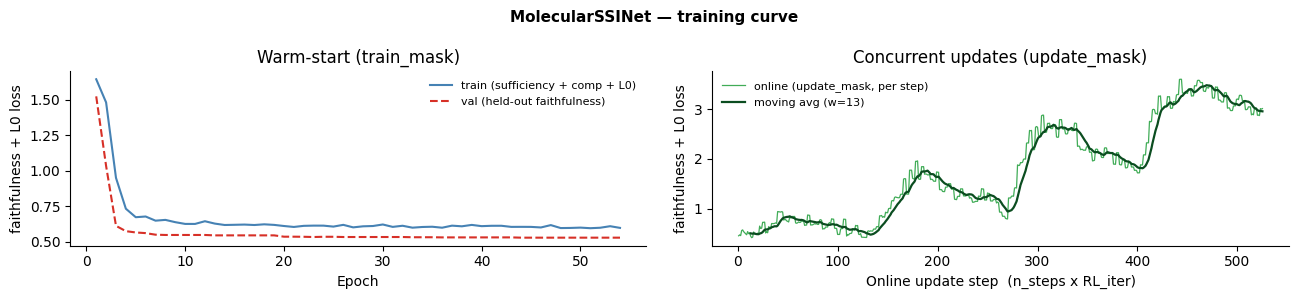


   Auto-selected molecule (best binding affinity): COc1ccc(-c2ccc(C(=O)c3ccc(N(=O)=O)cc3)cc2)cc1Cc1ccc(C(=O)c2ccccc2CNc2cccc(N(=O)=O)c2)cc1OC

[MolecularSSINet] 2D explanation: COc1ccc(-c2ccc(C(=O)c3ccc(N(=O)=O)cc3)cc2)cc1Cc1ccc(C(=O)c2ccccc2CNc2cccc(N(=O)=O)c2)cc1OC
[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/images/ssinet_atom_importance_structure.png


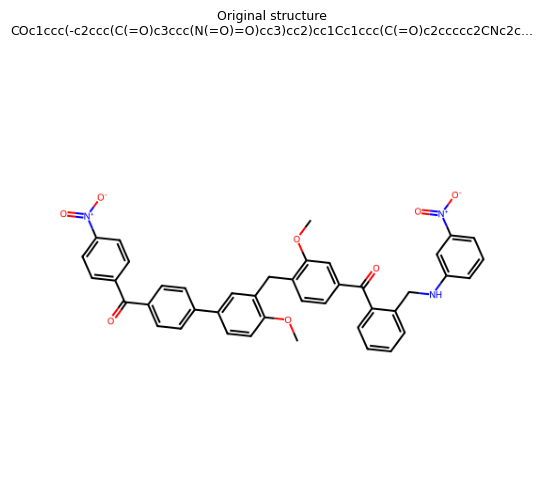

[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/images/ssinet_atom_importance_heatmap.png


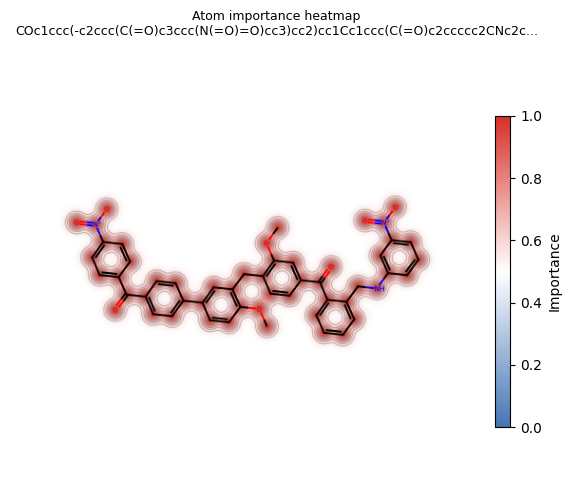

[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/images/ssinet_atom_importance_barchart.png


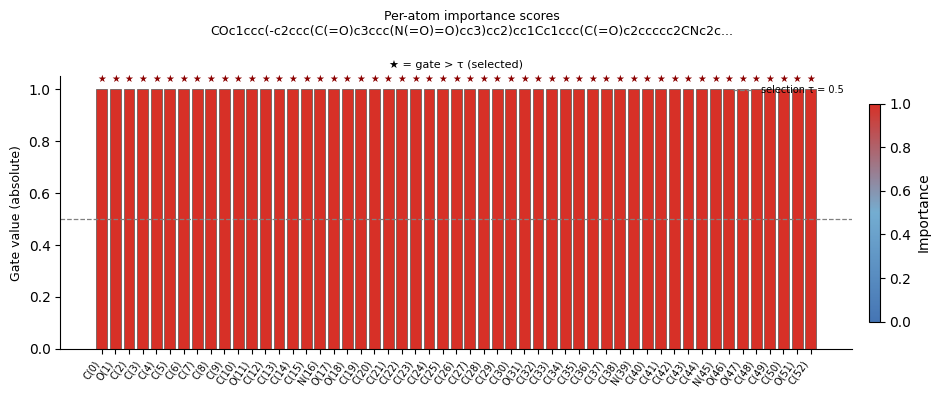


[MolecularSSINet] Selected atoms (gate > 0.5): C[0], O[1], C[2], C[3], C[4], C[5], C[6], C[7], C[8], C[9], C[10], O[11], C[12], C[13], C[14], C[15], N[16], O[17], O[18], C[19], C[20], C[21], C[22], C[23], C[24], C[25], C[26], C[27], C[28], C[29], C[30], O[31], C[32], C[33], C[34], C[35], C[36], C[37], C[38], N[39], C[40], C[41], C[42], C[43], C[44], N[45], O[46], O[47], C[48], C[49], C[50], O[51], C[52]
  Mean gate       : 1.000    Max gate: 1.000
  Active fraction : 53/53 atoms above τ

[MolecularSSINet] 3D explanation: COc1ccc(-c2ccc(C(=O)c3ccc(N(=O)=O)cc3)cc2)cc1Cc1ccc(C(=O)c2ccccc2CNc2cccc(N(=O)=O)c2)cc1OC
[MolecularSSINet] py3Dmol not found — run: pip install py3Dmol
[MolecularSSINet] Falling back to 2D visualize().


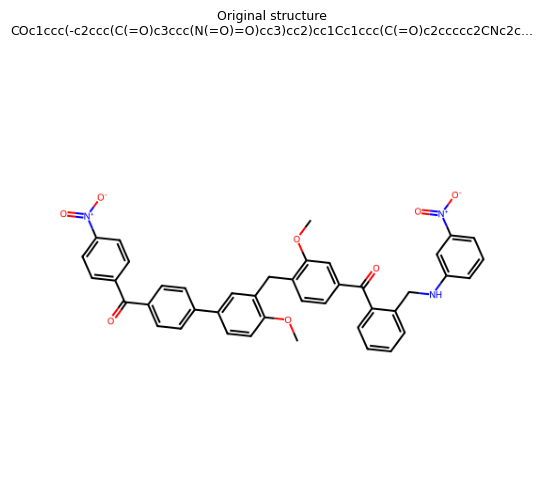

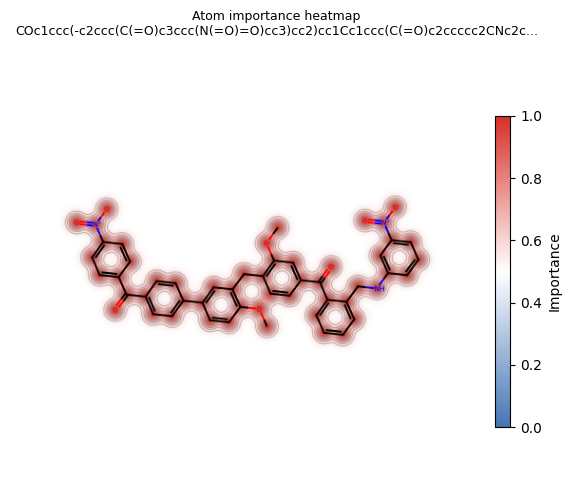

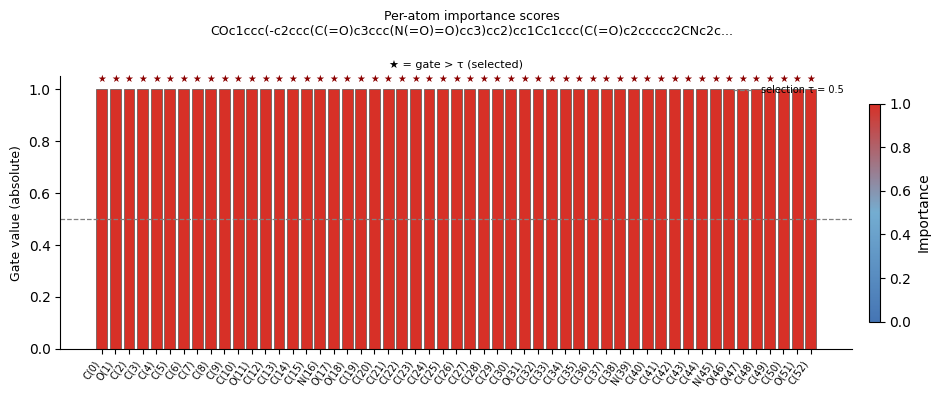


[MolecularSSINet] Selected atoms (gate > 0.5): C[0], O[1], C[2], C[3], C[4], C[5], C[6], C[7], C[8], C[9], C[10], O[11], C[12], C[13], C[14], C[15], N[16], O[17], O[18], C[19], C[20], C[21], C[22], C[23], C[24], C[25], C[26], C[27], C[28], C[29], C[30], O[31], C[32], C[33], C[34], C[35], C[36], C[37], C[38], N[39], C[40], C[41], C[42], C[43], C[44], N[45], O[46], O[47], C[48], C[49], C[50], O[51], C[52]
  Mean gate       : 1.000    Max gate: 1.000
  Active fraction : 53/53 atoms above τ

[MolecularSSINet] Running alpha sweep...
[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/plots/ssinet_alpha_sweep_1of2.png


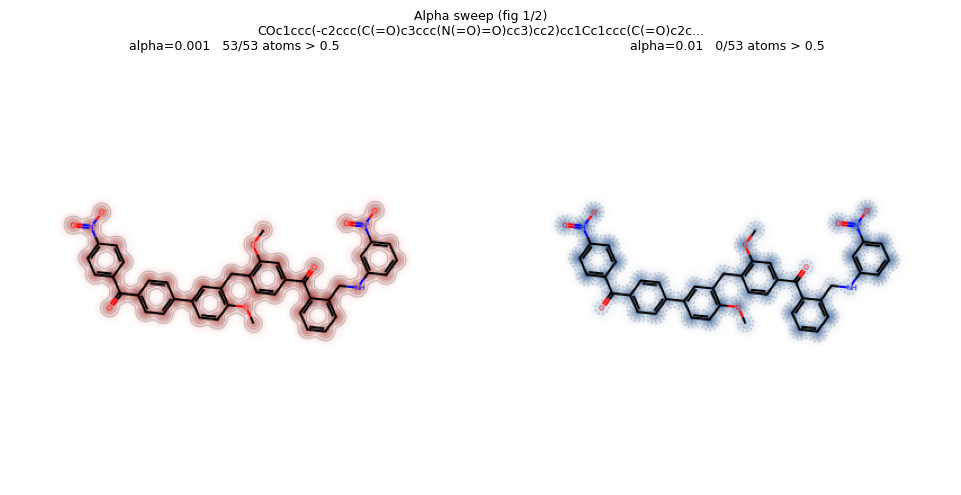

[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/plots/ssinet_alpha_sweep_2of2.png


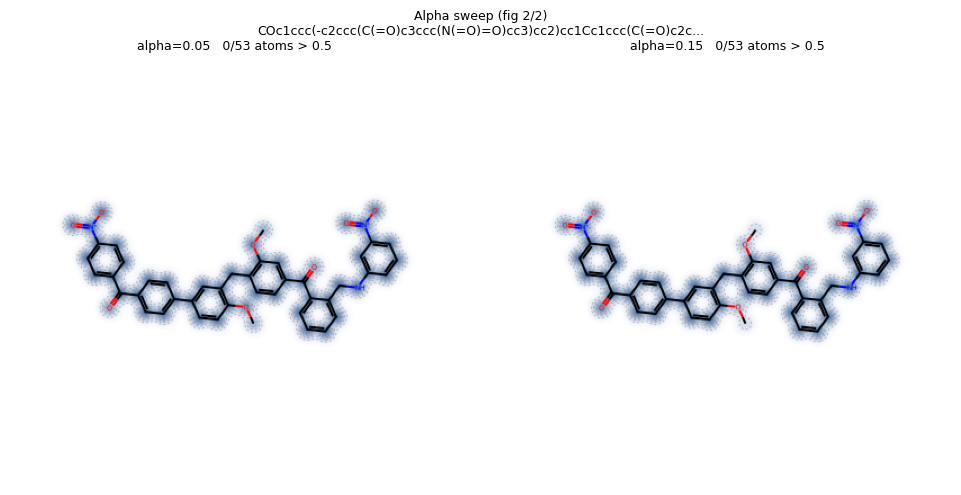

[MolecularSSINet] Saved: /kaggle/working/outputs/alternate_rewards/plots/ssinet_alpha_sweep_metrics.png


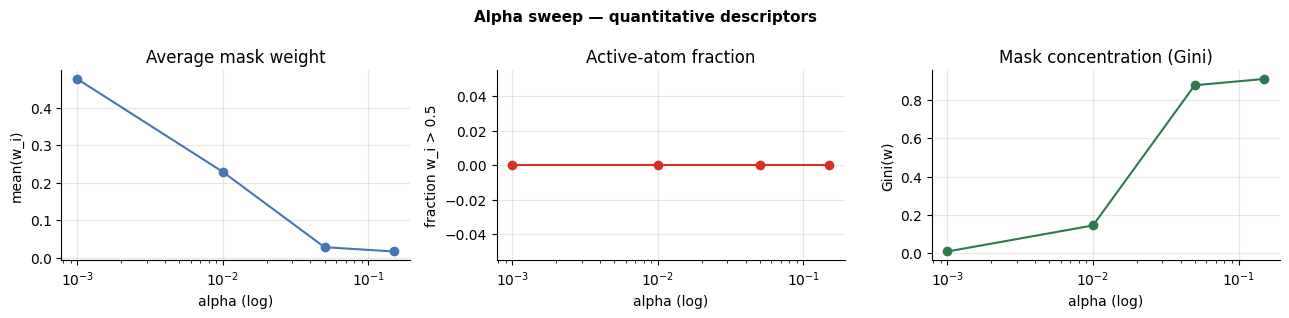


[MolecularSSINet] Alpha sweep — quantitative summary
    alpha   mean_w   max_w  active/total    Gini
    0.001    0.476   0.491      0/ 53       0.010
     0.01    0.229   0.376      0/ 53       0.146
     0.05    0.029   0.318      0/ 53       0.877
     0.15    0.017   0.280      0/ 53       0.910
[MolecularSSINet] Alpha sweep complete.

✅  Interpretability complete. Call ssinet.visualize(smi) or ssinet.visualize_3d(smi) on any molecule.


In [27]:
if USE_INTERPRET and ssinet is not None:
    print("=" * 60)
    print("🔍  MolecularSSINet — Final Visualisation")
    print("=" * 60)

    # ── Plot training curve (also saved to PLOTS_DIR) ───────────
    ssinet.plot_training_curve(
        save_path=os.path.join(PLOTS_DIR, "ssinet_training_curve.png")
    )

    # ── Pick best molecule to explain ───────────────────────────
    if INTERPRET_SMILES is not None:
        target_smiles = INTERPRET_SMILES
    elif 'smiles' in dir() and 'prediction' in dir() and len(smiles) > 0:
        best_idx      = int(np.argmin(prediction))
        target_smiles = smiles[best_idx]
        print(f"\n   Auto-selected molecule (best binding affinity): {target_smiles}")
    elif ssinet._best_smiles is not None:
        target_smiles = ssinet._best_smiles
        print(f"\n   Using best molecule from warm-start: {target_smiles}")
    else:
        target_smiles = _warmstart_smiles[0]
        print(f"\n   Using first warm-start SMILES: {target_smiles}")

    # ── 2-D heatmap ─────────────────────────────────────────────
    print(f"\n[MolecularSSINet] 2D explanation: {target_smiles}")
    atom_weights = ssinet.visualize(
        smiles    = target_smiles,
        save_path = os.path.join(IMAGES_DIR, "ssinet_atom_importance.png")
    )

    # ── Interactive 3-D view ─────────────────────────────────────
    print(f"\n[MolecularSSINet] 3D explanation: {target_smiles}")
    ssinet.visualize_3d(target_smiles)

    # ── Alpha sweep (analog of SSINet paper Fig. 7) ──────────────
    print("\n[MolecularSSINet] Running alpha sweep...")
    ssinet.alpha_sweep(target_smiles, alphas=(0.001, 0.01, 0.05, 0.15))

    print("\n✅  Interpretability complete. "
          "Call ssinet.visualize(smi) or ssinet.visualize_3d(smi) "
          "on any molecule.")
else:
    if not USE_INTERPRET:
        print("ℹ️  Interpretability disabled (USE_INTERPRET=False in config).")
    else:
        print("ℹ️  ssinet not initialised (PREDICTOR != 'gin').")


## 👀 Analysis & Visualization
Visualize training progress and generate/analyze molecules from the optimized model.

### 📈 Generate Plots

[Plots] Saved training curves → /kaggle/working/outputs/alternate_rewards/plots/training_curves.png


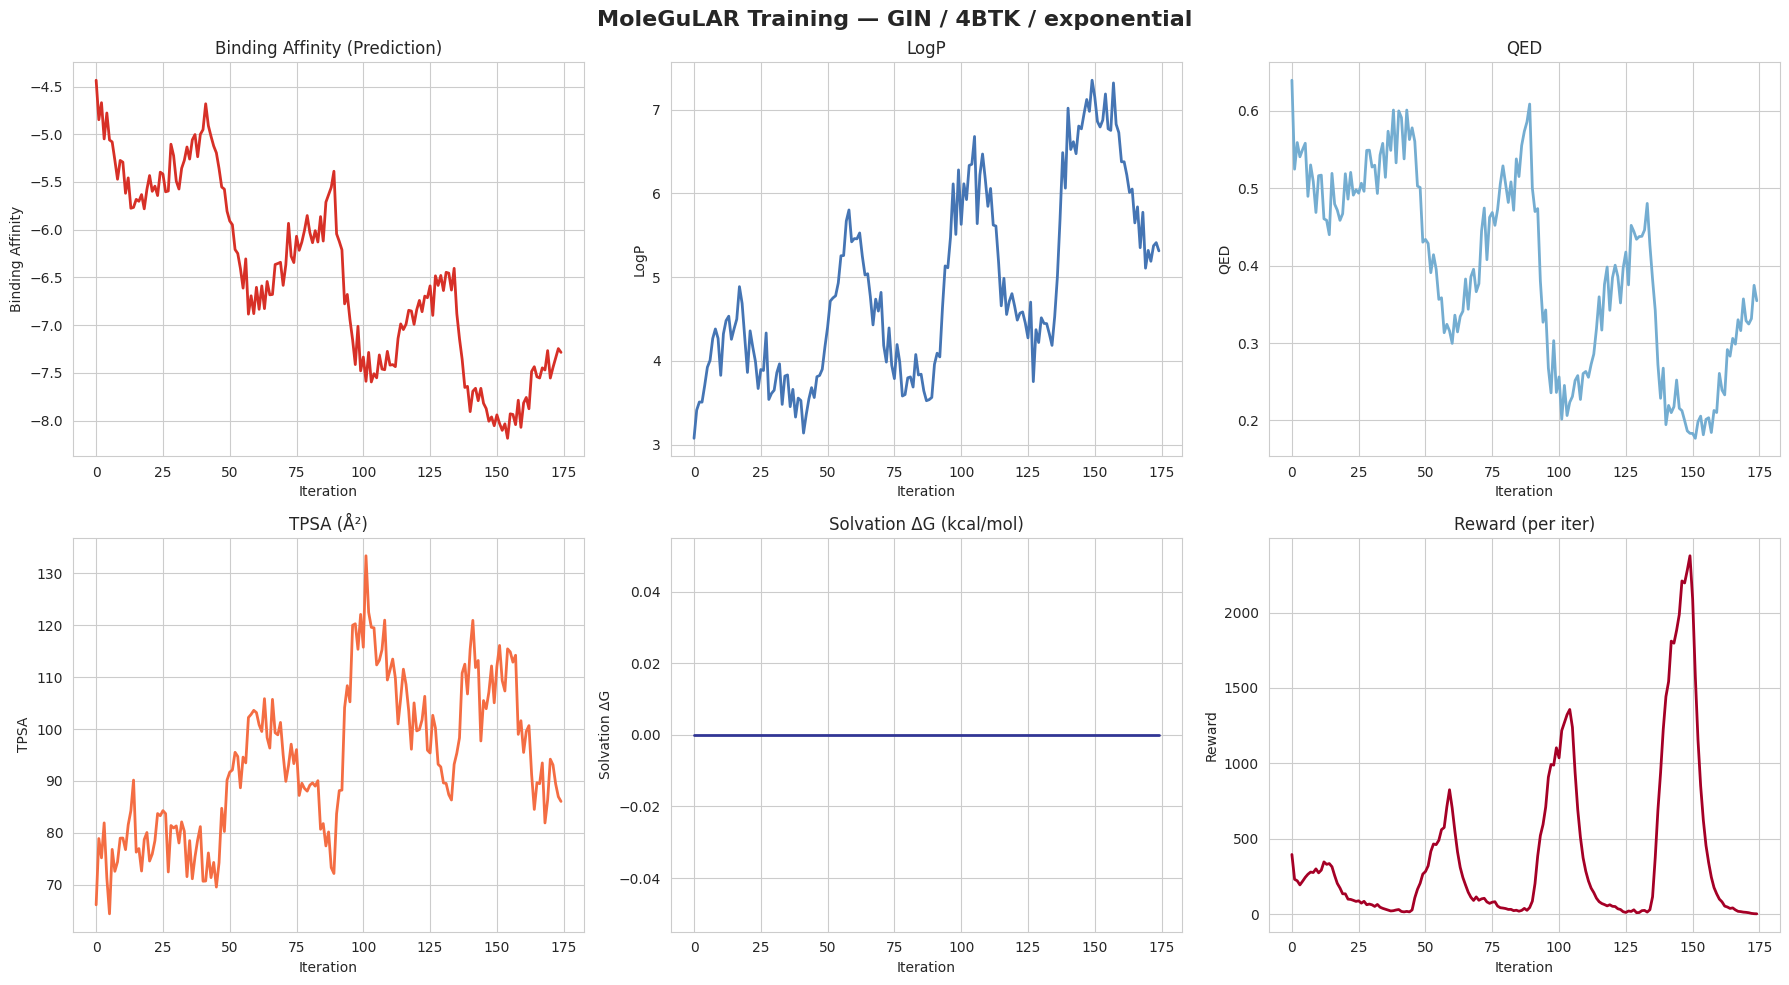

In [28]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"MoleGuLAR Training — {PREDICTOR.upper()} / {PROTEIN} / {REWARD_FUNCTION}", fontsize=16, fontweight='bold')

# bWr palette: deep-blue (#313695) → blue (#4575b4) → light-blue (#74add1)
#              → light-red (#f46d43) → red (#d73027) → deep-red (#a50026)
metrics = [
    (preds_history, "Binding Affinity (Prediction)", "#d73027"),   # bWr red
    (logp_history, "LogP", "#4575b4"),                             # bWr blue
    (qed_history, "QED", "#74add1"),                              # bWr light-blue
    (tpsa_history, "TPSA (Å²)", "#f46d43"),                       # bWr light-red
    (solvation_history, "Solvation ΔG (kcal/mol)", "#313695"),    # bWr deep-blue
    (rewards_history[-len(preds_history)*N_POLICY::N_POLICY] if len(rewards_history) > 0 else [], "Reward (per iter)", "#a50026"),  # bWr deep-red
]

for ax, (data, title, color) in zip(axes.flat, metrics):
    if len(data) > 0:
        ax.plot(data, color=color, linewidth=2)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(title.split("(")[0].strip())
    else:
        ax.set_visible(False)

plt.tight_layout()
_tc_path = os.path.join(PLOTS_DIR, 'training_curves.png')
fig.savefig(_tc_path, dpi=150, bbox_inches='tight')
print(f'[Plots] Saved training curves → {_tc_path}')
plt.show()

### 🧪 Generate Final Molecules

In [29]:
from tqdm import trange
print('🧬 Generating molecules from the optimised model...\n')

# ── Sample ────────────────────────────────────────────────────────────────────
_N_GEN = 1000
_raw_gen = []
for _ in trange(_N_GEN, desc='Sampling'):
    _raw_gen.append(generator.evaluate(gen_data, predict_len=120)[1:-1])

_sanitized = canonical_smiles(_raw_gen, sanitize=False, throw_warning=False)[:-1]
_unique_set = list(np.unique(_sanitized))[1:]   # drop empty string
print(f'Sampled {_N_GEN} → {len(_unique_set)} unique valid SMILES')

# ── Score with GIN predictor ──────────────────────────────────────────────────
_smiles_ok, _preds, _ = my_predictor.predict(_unique_set, test=True, use_tqdm=True)

# ── Build full property profile ───────────────────────────────────────────────
import pandas as _pd
from rdkit.Chem import Descriptors as _Desc
from rdkit.Chem.QED import qed as _qed_fn

_records = []
for _smi, _pred in zip(_smiles_ok, _preds):
    _mol = Chem.MolFromSmiles(_smi)
    if _mol is None:
        continue
    try:
        _records.append({
            'SMILES':       _smi,
            'BA_predicted': round(float(_pred), 4),
            'LogP':         round(MolLogP(_mol), 3),
            'QED':          round(_qed_fn(_mol), 3),
            'TPSA':         round(CalcTPSA(_mol), 2),
            'MW':           round(_Desc.MolWt(_mol), 2),
            'HBD':          int(_Desc.NumHDonors(_mol)),
            'HBA':          int(_Desc.NumHAcceptors(_mol)),
            'RotBonds':     int(_Desc.NumRotatableBonds(_mol)),
        })
    except Exception:
        pass

# ── Sort by BA (best = lowest = most negative) ────────────────────────────────
_df_mols = _pd.DataFrame(_records).sort_values('BA_predicted').reset_index(drop=True)
print(f'{len(_df_mols)} molecules profiled and ranked by binding affinity')
print(_df_mols.head(10).to_string(index=False))

# ── Save CSV ──────────────────────────────────────────────────────────────────
_csv_path = os.path.join(NEW_MOLECULES_DIR, f'generated_molecules_{REMARKS}.csv')
_df_mols.to_csv(_csv_path, index=False)
print(f'\n✅  Saved {len(_df_mols)}-row CSV → {_csv_path}')

# ── Set unique_mols = BA-sorted list (used by batch_interpret below) ──────────
# Row 0 in the CSV == unique_mols[0] == top-1 molecule in all plots
unique_mols = list(_df_mols['SMILES'])
final_molecules = unique_mols   # keep alias for any downstream cells

print(f'\nValidity:   {len(_unique_set)/max(_N_GEN,1)*100:.1f}%')
print(f'Uniqueness: {len(_unique_set)/max(len(_raw_gen),1)*100:.1f}%')
print(f'Profiled:   {len(_df_mols)}')
print(f'unique_mols[0] (best BA): {unique_mols[0] if unique_mols else "—"}')

# ── Alias for downstream cells (histograms, etc.) ────────────────────────────
df = _df_mols   # LogP, QED, TPSA, MW, HBD, HBA, RotBonds, BA_predicted

# ── Push CSV + model to GitHub ────────────────────────────────────────────────
save_snapshot()
push_to_github(label='molecules_csv')


🧬 Generating molecules from the optimised model...



Sampling: 100%|██████████| 1000/1000 [01:35<00:00, 10.51it/s]


Sampled 1000 → 920 unique valid SMILES


Calculating predictions...: 100%|██████████| 920/920 [00:01<00:00, 501.00it/s]


869 molecules profiled and ranked by binding affinity
                                                                                      SMILES  BA_predicted  LogP   QED   TPSA     MW  HBD  HBA  RotBonds
Cc1cc(c2ccc(-c3c(N(=O)=O)cc(C(=O)O)nc3c3ccccc3)cc2)ccc1Oc1ccc(S(=O)(=O)c2ccc(N(=O)=O)cc2)cc1       -8.9940 8.531 0.108 179.84 687.69    1    9        10
          COOC(=O)c1ccc(N2C(=O)c3ccccc3C2c2ccc(C(=O)c3cccc(C(=O)c4cccc(N(=O)=O)c4)c3)cc2)cc1       -8.9737 6.525 0.079 133.12 612.59    0    8         9
  Cc1ccc(C(=O)c2ccc(N3C(=O)C(CC(=O)c4ccc(S(=O)(=O)c5ccc(C(=O)O)cc5)cc4)=CN3Cc3ccccc3)cc2)cc1       -8.9028 6.183 0.163 132.51 670.74    1    6        11
  O=C(c1ccc(C(=O)c2ccc(N(=O)=O)cc2)cc1)c1ccc(-c2ccc(C(=O)c3ccc(C(=O)c4ccccc4)c(Cl)c3)cc2)cc1       -8.8727 8.839 0.083 111.42 650.09    0    6        10
     CN(c1cccc(C(=O)c2ccc(N(=O)=O)cc2)c1)c1cccc(C(=O)c2ccc(S(=O)(=O)c3cccc(N(=O)=O)c3)cc2)c1       -8.8214 6.566 0.096 157.80 621.63    0    9        10
COc1ccc(c2ccc(S(=O)(=O)c3ccc

### 🔬 Batch Interpretation
Aggregate mask importance across the **top-N generated molecules** to identify recurring pharmacophoric features rather than single-molecule quirks.


[BatchInterpret] Pool: 869 molecules → keeping top 50
  Valid: 50 / 50  (failed: 0)
[BatchInterpret] Saved: batch_atom_types.png


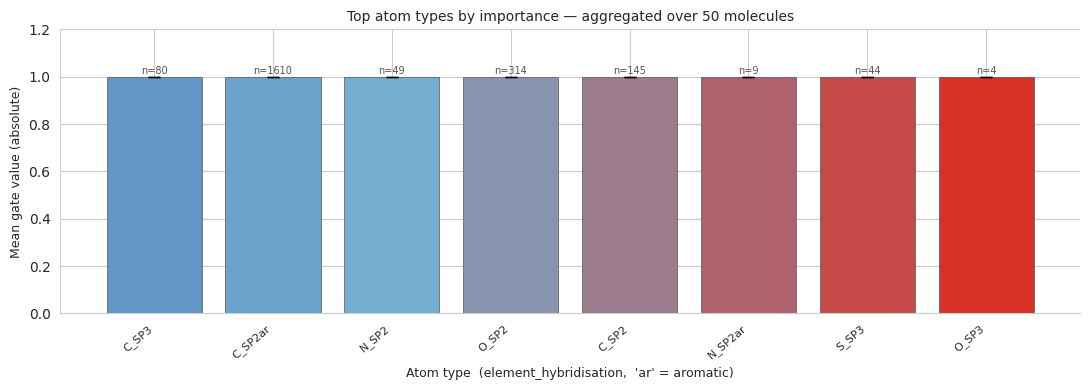

[BatchInterpret] Saved: batch_elem_freq.png


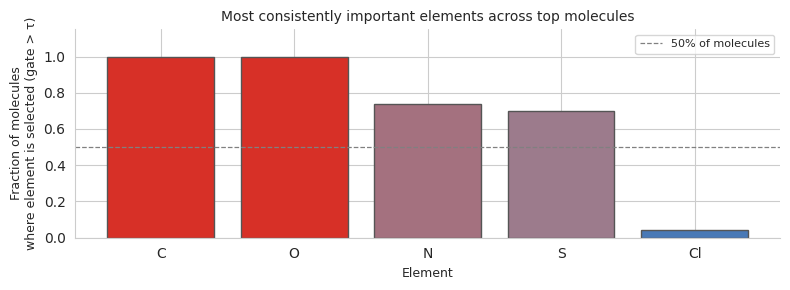

[BatchInterpret] Saved: batch_violin.png


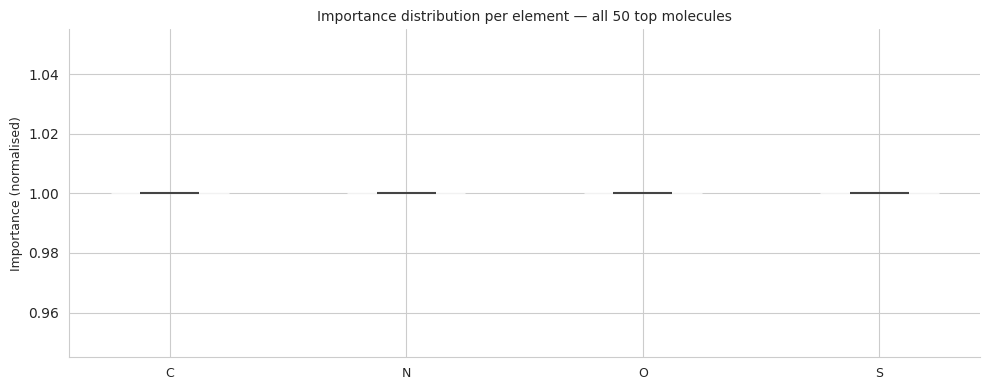

[BatchInterpret] Saved: batch_top5_heatmaps_1of3.png


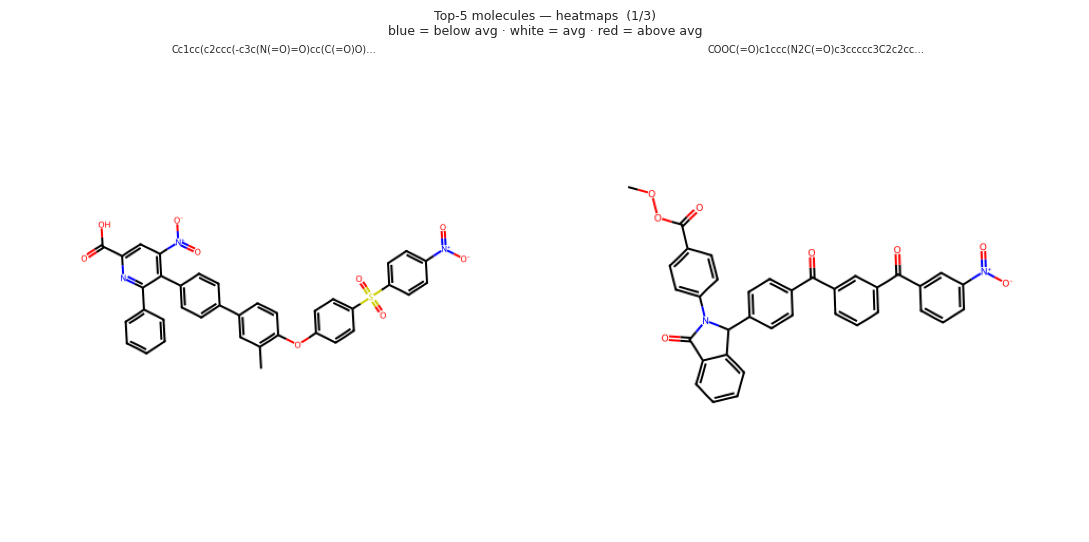

[BatchInterpret] Saved: batch_top5_heatmaps_2of3.png


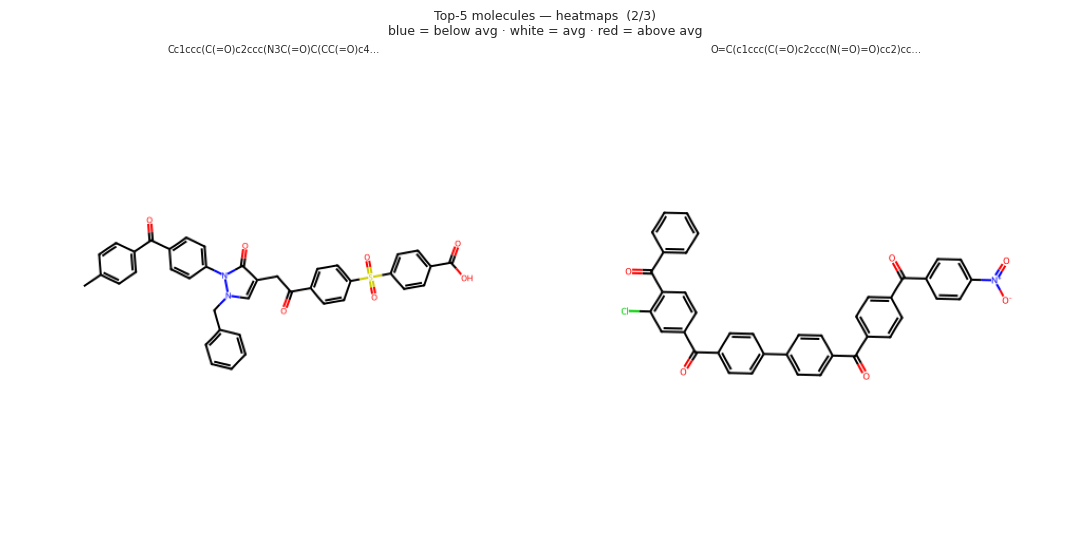

[BatchInterpret] Saved: batch_top5_heatmaps_3of3.png


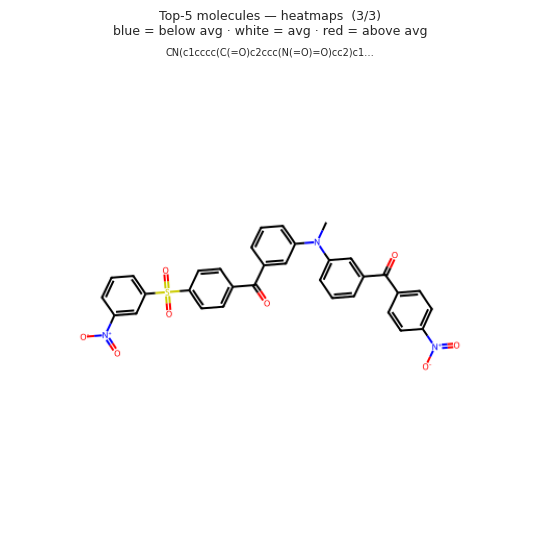


[BatchInterpret] SUMMARY
  Molecules analysed : 50

  Top 5 atom types by mean importance:
    C_SP3               mean=1.000  ±0.000  (n=80 atoms)
    C_SP2ar             mean=1.000  ±0.000  (n=1610 atoms)
    N_SP2               mean=1.000  ±0.000  (n=49 atoms)
    O_SP2               mean=1.000  ±0.000  (n=314 atoms)
    C_SP2               mean=1.000  ±0.000  (n=145 atoms)

  Elements most frequently in the top-5 important atoms:
    C     100.0% of molecules  (50/50)
    O     100.0% of molecules  (50/50)
    N      74.0% of molecules  (37/50)
    S      70.0% of molecules  (35/50)
    Cl      4.0% of molecules  (2/50)


In [30]:
def batch_interpret(ssinet, smiles_list, top_n=50, predictor=None, save_dir=None, images_dir=None):
    """
    Aggregate SSINet atom-importance scores across the top-N molecules by
    binding affinity and produce three summary figures:

      A — Mean importance per atom type (element + hybridisation)
      B — Fraction of molecules where each element appears in the top-5 atoms
      C — Importance distribution violin plot per element

    Args:
        ssinet      — trained MolecularSSINet
        smiles_list — pool of generated SMILES (ranked by predictor if provided)
        top_n       — number of top molecules to analyse
        predictor   — GINPredictor used for ranking (None = use order as-is)
        save_dir    — directory for saved PNGs (None = don't save)

    Returns a dict with raw aggregation data for further custom analysis.
    """
    from collections import defaultdict

    # ── 1. Rank by binding affinity ───────────────────────────────────────────
    print(f"\n[BatchInterpret] Pool: {len(smiles_list)} molecules → keeping top {top_n}")
    if predictor is not None:
        # Use ssinet._gin_embed in chunks — avoids the device mismatch that
        # predictor.predict() causes when args['device'] != the net's device.
        CHUNK = 64
        all_valid, all_affs = [], []
        for _start in range(0, len(smiles_list), CHUNK):
            _chunk = smiles_list[_start: _start + CHUNK]
            _bg, _nf, _ef, _valid = ssinet._batch_smiles(_chunk)
            if _bg is None:
                continue
            _, _, _scores = ssinet._gin_embed(_bg, _nf, _ef)
            all_valid.extend(_valid)
            all_affs.extend(_scores.squeeze(-1).cpu().tolist())
        if all_valid:
            ranked     = sorted(zip(all_valid, all_affs), key=lambda x: x[1])
            top_smiles = [s for s, _ in ranked[:top_n]]
            top_affs   = [a for _, a in ranked[:top_n]]
            print(f"  Affinity range in top-{top_n}: "
                  f"[{top_affs[0]:.3f}, {top_affs[-1]:.3f}]")
        else:
            top_smiles = smiles_list[:top_n]
            top_affs   = [None] * top_n
    else:
        top_smiles = smiles_list[:top_n]
        top_affs   = [None] * top_n

    # ── 2. Compute per-atom weights ───────────────────────────────────────────
    all_weights = {}   # smiles -> (mol, w_abs ndarray)
    failed = 0
    for smi in top_smiles:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            failed += 1
            continue
        try:
            w = ssinet.get_atom_weights(smi)
            n = mol.GetNumAtoms()
            if len(w) != n:
                w = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(w)), w)
            # ABSOLUTE gate scale (no per-molecule min-max): keeps molecules
            # comparable and lets pharmacophore-free molecules stay low, so they
            # add nothing to the selected-element tally below (abstention).
            w_abs = np.clip(w, 0.0, 1.0)
            AllChem.Compute2DCoords(mol)
            all_weights[smi] = (mol, w_abs)
        except Exception:
            failed += 1

    n_mols = len(all_weights)
    print(f"  Valid: {n_mols} / {len(top_smiles)}  (failed: {failed})")
    if n_mols == 0:
        print("[BatchInterpret] No valid molecules — aborting.")
        return {}

    # ── 3. Aggregate by atom type ─────────────────────────────────────────────
    type_weights = defaultdict(list)   # "N_SP2ar" -> [w1, w2, ...]
    elem_weights = defaultdict(list)   # "N"       -> [w1, w2, ...]
    sel_elem_count = defaultdict(int)  # element -> # molecules where it is SELECTED

    # Absolute selection threshold inherited from the SSINet (Hard-Concrete gate).
    _sel_tau = float(getattr(ssinet, "select_tau", 0.5))
    for smi, (mol, w_abs) in all_weights.items():
        # Elements owning >=1 selected atom (gate > tau) in THIS molecule. Counting
        # each element at most once per molecule keeps the fraction in [0, 1]; an
        # abstaining molecule (no atom > tau) contributes nothing.
        sel_elems = {mol.GetAtomWithIdx(int(i)).GetSymbol()
                     for i in np.where(w_abs > _sel_tau)[0]}
        for i, atom in enumerate(mol.GetAtoms()):
            hyb  = str(atom.GetHybridization()).split(".")[-1]
            arom = "ar" if atom.GetIsAromatic() else ""
            key  = f"{atom.GetSymbol()}_{hyb}{arom}"
            type_weights[key].append(float(w_abs[i]))
            elem_weights[atom.GetSymbol()].append(float(w_abs[i]))
        for e in sel_elems:
            sel_elem_count[e] += 1

    type_stats  = {k: (np.mean(v), np.std(v), len(v))
                   for k, v in type_weights.items() if len(v) >= 3}
    sorted_types = sorted(type_stats.items(), key=lambda x: -x[1][0])
    elem_freq    = sorted(sel_elem_count.items(), key=lambda x: -x[1])

    # ── 4a. Plot A — mean importance by atom type ─────────────────────────────
    top_types = sorted_types[:15]
    labels = [t[0] for t in top_types]
    means  = [t[1][0] for t in top_types]
    stds   = [t[1][1] for t in top_types]
    counts = [t[1][2] for t in top_types]

    if not top_types:
        print("[BatchInterpret] ⚠  Plot A skipped: no atom type has ≥3 occurrences "
              f"across {n_mols} molecules — increase top_n or run more iterations.")
    else:
        _max_std  = max(stds) if stds else 0.0
        _max_mean = max(means) if means else 0.0
        from matplotlib.colors import LinearSegmentedColormap as _LSC_ba
        _ba_cmap = _LSC_ba.from_list('bWr_bar', ['#4575b4', '#74add1', '#d73027'])  # bWr blue→red
        fig1, ax1 = plt.subplots(figsize=(11, 4))
        colors = _ba_cmap(np.linspace(0.3, 1.0, len(labels)))
        bars   = ax1.bar(labels, means, yerr=stds, color=colors,
                         capsize=4, edgecolor="#555", linewidth=0.5)
        for bar, c in zip(bars, counts):
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + _max_std * 0.08 + 0.01,
                     f"n={c}", ha="center", fontsize=7, color="#555")
        ax1.set_xlabel("Atom type  (element_hybridisation,  'ar' = aromatic)", fontsize=9)
        ax1.set_ylabel("Mean gate value (absolute)", fontsize=9)
        ax1.set_title(
            f"Top atom types by importance — aggregated over {n_mols} molecules", fontsize=10)
        ax1.set_ylim(0, min(1.25, _max_mean + _max_std + 0.2))
        ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
        plt.xticks(rotation=40, ha="right", fontsize=8)
        plt.tight_layout()
        if save_dir:
            fig1.savefig(os.path.join(save_dir, "batch_atom_types.png"),
                         dpi=150, bbox_inches="tight")
            print("[BatchInterpret] Saved: batch_atom_types.png")
        plt.show()

    # ── 4b. Plot B — fraction of molecules where element is SELECTED (gate>τ) ─
    elems = [e for e, _ in elem_freq]
    freqs = [c / n_mols for _, c in elem_freq]

    if not elem_freq:
        print("[BatchInterpret] ⚠  Plot B skipped: no element frequency data collected.")
    else:
        _max_freq = max(freqs) if freqs else 1.0
        if _max_freq == 0: _max_freq = 1.0
        from matplotlib.colors import LinearSegmentedColormap as _LSC_bb
        _bb_cmap = _LSC_bb.from_list('bWr_bar', ['#4575b4', '#74add1', '#d73027'])  # bWr blue→red
        fig2, ax2 = plt.subplots(figsize=(8, 3))
        colors2 = _bb_cmap(np.array(freqs) / _max_freq)
        ax2.bar(elems, freqs, color=colors2, edgecolor="#555")
        ax2.axhline(0.5, color="gray", linewidth=0.9, linestyle="--",
                    label="50% of molecules")
        ax2.set_xlabel("Element", fontsize=9)
        ax2.set_ylabel("Fraction of molecules\nwhere element is selected (gate > τ)", fontsize=9)
        ax2.set_title("Most consistently important elements across top molecules",
                      fontsize=10)
        ax2.set_ylim(0, 1.15)
        ax2.legend(fontsize=8)
        ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
        plt.tight_layout()
        if save_dir:
            fig2.savefig(os.path.join(save_dir, "batch_elem_freq.png"),
                         dpi=150, bbox_inches="tight")
            print("[BatchInterpret] Saved: batch_elem_freq.png")
        plt.show()

    # ── 4c. Plot C — importance violin per element ────────────────────────────
    elem_data   = {k: v for k, v in elem_weights.items() if len(v) >= 3}
    elem_sorted = sorted(elem_data.items(), key=lambda x: -np.mean(x[1]))

    if not elem_sorted:
        print("[BatchInterpret] ⚠  Plot C skipped: no element has ≥3 occurrences "
              f"across {n_mols} molecules. Increase top_n or run more iterations.")
    else:
        from matplotlib.colors import LinearSegmentedColormap as _LSC_bc
        _bc_cmap = _LSC_bc.from_list('bWr_bar', ['#4575b4', '#74add1', '#d73027'])  # bWr blue→red
        fig3, ax3 = plt.subplots(figsize=(10, 4))
        vp = ax3.violinplot(
            [v for _, v in elem_sorted],
            positions=range(len(elem_sorted)),
            showmedians=True, showextrema=False,
        )
        means3 = [np.mean(v) for _, v in elem_sorted]
        _vmin, _vmax = min(means3), max(means3)
        if _vmin == _vmax: _vmax = _vmin + 1e-6
        norm3  = plt.Normalize(_vmin, _vmax)
        for body, m in zip(vp["bodies"], means3):
            body.set_facecolor(_bc_cmap(norm3(m)))
            body.set_alpha(0.75)
        vp["cmedians"].set_color("#444")
        vp["cmedians"].set_linewidth(1.5)
        ax3.set_xticks(list(range(len(elem_sorted))))
        ax3.set_xticklabels([k for k, _ in elem_sorted], fontsize=9)
        ax3.set_ylabel("Importance (normalised)", fontsize=9)
        ax3.set_title(
            f"Importance distribution per element — all {n_mols} top molecules", fontsize=10)
        ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
        plt.tight_layout()
        if save_dir:
            fig3.savefig(os.path.join(save_dir, "batch_violin.png"),
                         dpi=150, bbox_inches="tight")
            print("[BatchInterpret] Saved: batch_violin.png")
        plt.show()

    # ── 4d. Plot D — top-N molecule heatmaps (max 2 per figure) ──────────────
    _top5 = list(all_weights.items())[:5]   # ordered by affinity (best first)
    if not _top5:
        print("[BatchInterpret] ⚠  Plot D skipped: no valid molecules in pool.")
    else:
        from rdkit.Chem.Draw import SimilarityMaps as _SM_d
        from matplotlib.colors import LinearSegmentedColormap as _LSC_d
        _WtRd_d = _LSC_d.from_list('bWr', ['#4575b4', 'white', '#d73027'])

        # chunk into rows of 2 so each figure has at most 2 molecules
        _COLS   = 2
        _chunks = [_top5[_s:_s+_COLS] for _s in range(0, len(_top5), _COLS)]
        _total  = len(_top5)

        for _fig_n, _chunk in enumerate(_chunks, start=1):
            _nc   = len(_chunk)
            _fig4, _axes4 = plt.subplots(1, _nc, figsize=(_nc * 5.5, 5.5),
                                          squeeze=False)
            _axes4 = _axes4[0]   # shape (1, _nc) → (_nc,)
            _fig4.suptitle(
                f"Top-{_total} molecules — heatmaps  "
                f"({_fig_n}/{len(_chunks)})\n"
                "blue = below avg · white = avg · red = above avg",
                fontsize=9)
            for _ax, (_smi, (_mol_h, _w_h)) in zip(_axes4, _chunk):
                _wc_h = _w_h - _w_h.mean()
                _lbl  = (_smi[:35] + '…') if len(_smi) > 35 else _smi
                _ax.set_title(_lbl, fontsize=7, pad=4)
                try:
                    from rdkit.Chem.Draw import rdMolDraw2D as _rdd_d
                    from PIL import Image as _PIL_d
                    from io import BytesIO as _BS_d
                    _dd = _rdd_d.MolDraw2DCairo(500, 450)
                    _SM_d.GetSimilarityMapFromWeights(
                        _mol_h, _wc_h.tolist(), _dd,
                        colorMap=_WtRd_d, contourLines=8)
                    _dd.FinishDrawing()
                    _ax.imshow(_PIL_d.open(_BS_d(_dd.GetDrawingText())))
                except TypeError:
                    try:
                        _SM_d.GetSimilarityMapFromWeights(
                            _mol_h, _wc_h.tolist(),
                            colorMap=_WtRd_d, contourLines=8,
                            size=(500, 450), ax=_ax)
                    except Exception:
                        _ax.text(0.5, 0.5, 'render\nfailed',
                                 ha='center', va='center',
                                 transform=_ax.transAxes, fontsize=8, color='gray')
                except Exception:
                    _ax.text(0.5, 0.5, 'render\nfailed',
                             ha='center', va='center',
                             transform=_ax.transAxes, fontsize=8, color='gray')
                _ax.axis('off')
            plt.tight_layout()
            if save_dir:
                _fname = f'batch_top{_total}_heatmaps_{_fig_n}of{len(_chunks)}.png'
                _d_out = images_dir if images_dir else save_dir
                _fig4.savefig(os.path.join(_d_out, _fname),
                              dpi=150, bbox_inches='tight')
                print(f'[BatchInterpret] Saved: {_fname}')
            plt.show()

    # ── 5. Summary ────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("[BatchInterpret] SUMMARY")
    print("=" * 60)
    print(f"  Molecules analysed : {n_mols}")
    print(f"\n  Top 5 atom types by mean importance:")
    for name, (mean, std, cnt) in sorted_types[:5]:
        print(f"    {name:18s}  mean={mean:.3f}  ±{std:.3f}  (n={cnt} atoms)")
    print(f"\n  Elements most frequently in the top-5 important atoms:")
    for elem, cnt in elem_freq[:6]:
        print(f"    {elem:4s}  {cnt/n_mols*100:5.1f}% of molecules  ({cnt}/{n_mols})")
    print("=" * 60)

    return {
        "type_stats":    sorted_types,
        "elem_freq":     elem_freq,
        "elem_weights":  elem_data,
        "all_weights":   all_weights,
    }


# ── Run batch interpretation ──────────────────────────────────────────────────
if USE_INTERPRET and ssinet is not None:
    # Use unique_mols from cell 60 (final generated molecules).
    # If that cell hasn't run yet, fall back to the warm-start SMILES.
    _pool = unique_mols if "unique_mols" in dir() and unique_mols else _warmstart_smiles
    batch_results = batch_interpret(
        ssinet,
        smiles_list = _pool,
        top_n       = 50,
        predictor   = None,        # unique_mols already BA-sorted by my_predictor
        save_dir    = PLOTS_DIR,   # statistical plots → plots/
        images_dir  = IMAGES_DIR,  # molecule heatmaps → images/
    )
else:
    print("ℹ️  Batch interpretation skipped (USE_INTERPRET=False or ssinet not initialised).")


####  📊 Property Distribution Plots  

[Plots] Saved property distributions → /kaggle/working/outputs/alternate_rewards/plots/property_distributions.png


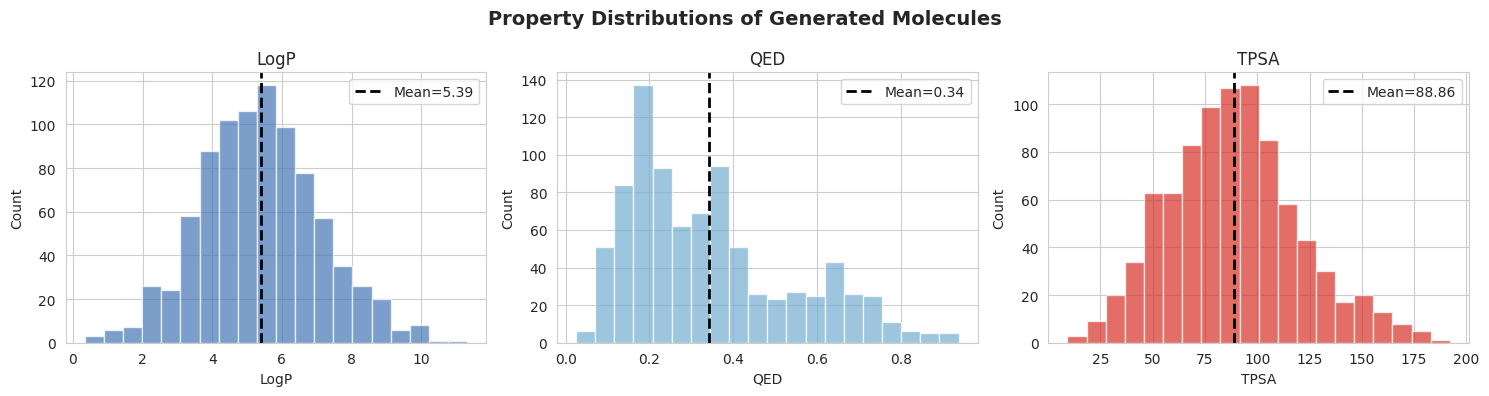

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Property Distributions of Generated Molecules", fontsize=14, fontweight='bold')

# bWr palette: LogP=blue, QED=light-blue, TPSA=red
for ax, col, color in zip(axes, ['LogP', 'QED', 'TPSA'], ['#4575b4', '#74add1', '#d73027']):
    if col in df.columns:
        ax.hist(df[col], bins=20, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=2, label=f'Mean={df[col].mean():.2f}')
        ax.set_title(col, fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
_hist_path = os.path.join(PLOTS_DIR, 'property_distributions.png')
fig.savefig(_hist_path, dpi=150, bbox_inches='tight')
print(f'[Plots] Saved property distributions → {_hist_path}')
plt.show()

## 🔧 (Optional) AutoDock-GPU
Setup> **Only needed if `PREDICTOR = "dock"`**. This section installs AutoDock-GPU and MGLTools to perform actual docking calculations.⚠️ This requires a GPU runtime and may take 10-15 minutes to build.

In [32]:
# ── OPTIONAL: Install AutoDock-GPU ──
# Uncomment and run these cells only if you need docking

# !apt-get update && apt-get install -y wget bzip2 ca-certificates curl git libxrender1
# !git clone https://github.com/ccsb-scripps/AutoDock-GPU /content/AutoDock-GPU
# %cd /content/AutoDock-GPU
# !export GPU_INCLUDE_PATH=/usr/local/cuda/include && \
#  export GPU_LIBRARY_PATH=/usr/local/cuda/lib64 && \
#  make DEVICE=CUDA NUMWI=64
# %cd {OPTIMIZER_DIR}

# ── OPTIONAL: Install MGLTools ──
# !tar -xzf {REPO_DIR}/mgltools_x86_64Linux2_1.5.6.tar_.gz -C /content/
# !cd /content/mgltools_x86_64Linux2_1.5.6 && ./install.sh

# import os
# os.environ['AUTODOCK_GPU'] = '/content/AutoDock-GPU'
# os.environ['MGL_TOOLS_PATH'] = '/content/mgltools_x86_64Linux2_1.5.6'

 ## 📤 GitHub Push

In [33]:
# ── Post-training GitHub push ─────────────────────────────────────────────────
# The training loop (Cell 53) already pushed a "final" snapshot.
# This cell re-pushes only if PUSH_TO_GITHUB is True and something
# was added after training (e.g. SSINet plots, analysis figures).

print("=" * 60)
print("📤 Post-training push (analysis outputs)")
print("=" * 60)

# Sync any new files produced by analysis cells into KAGGLE_OUTPUT_DIR
save_snapshot()
push_to_github(label="post_analysis")

print("\nDone. Check your GitHub repo → outputs/ folder.")


📤 Post-training push (analysis outputs)
[Snapshot] → /kaggle/working/outputs/alternate_rewards/checkpoints
[GitHub] ✅ Pushed: [AUTO] alternate-rewards-SSINet | post_analysis @ 20260603_113443

Done. Check your GitHub repo → outputs/ folder.


## 🎉 Done!You've successfully run the MoleGuLAR pipeline.
 ### Key outputs:
 - **Trained model** saved to `models/model_<reward>_<remarks>`- **Generated molecules** with optimized binding affinity and drug-like properties
 - **Training curves** showing optimization progress
 ### Next Steps
 - Increase `NUM_ITERATIONS` to 175 for full training
 - Enable multi-objective: set `USE_LOGP=True`, `USE_QED=True`, `SWITCH_MODE=True`
 - Try different proteins or reward functions- Use the Analysis notebook (`Analysis/Analysis.ipynb`) for deeper analysis